# 04 — 集合竞价因子生产与因子深度扩展

## Notebook职责

本 notebook 只负责将09:15–09:25集合竞价的原始订单、成交和盘口数据
加工成09:30决策时已经可见的股票日因子。它不使用09:30后的收益率，
不计算IC，也不选择“最佳”阈值。

## Index

1. 数据准备与竞价窗口；
2. 基础委托、撤单、方向和时序特征；
3. 固定50万元大单母因子；
4. 盘口深度、价格发现与历史状态；
5. 预测就绪宽表及质量检查；
6. 大单因子深度工厂：
   - 标准订单事件表；
   - 固定金额阈值；
   - `full/post920`时间窗口；
   - 长表质量审计与导出；
7. 后续深化协议：相对规模、最后60/30秒、持续与反转。

## 研究边界

- 当前固定50万元大单定义继续保留，保证既有宽表兼容；
- 新阈值实验使用长表，不向正式宽表一次性增加大量列；
- “大单”是订单规模代理，不等于真实机构账户；
- 最佳阈值、IC和收益率评价全部在Notebook 05完成。


## CODE
### Preparation

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

EPS = 1e-9

In [3]:
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

from src.ddb_client import connect_ddb

session = connect_ddb()

In [4]:
DB_PATH = "dfs://quota"

START_DATE = "2026.01.01"
END_DATE = "2026.04.10"

AUCTION_START = "09:15:00"
AUCTION_END = "09:25:00"

print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Auction window:", AUCTION_START, "to", AUCTION_END)
table_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")
qorder = loadTable("{DB_PATH}", "qorder")
qknock = loadTable("{DB_PATH}", "qknock")
"""

session.run(table_script)

print("Defined DolphinDB tables:")
print("- qtick  : Market State / Snapshot Data")
print("- qorder : Market Intention / Order Data")
print("- qknock : Market Execution / Trade Data")

Database: dfs://quota
Sample period: 2026.01.01 to 2026.04.10
Auction window: 09:15:00 to 09:25:00
Defined DolphinDB tables:
- qtick  : Market State / Snapshot Data
- qorder : Market Intention / Order Data
- qknock : Market Execution / Trade Data


In [6]:
# ============================================================
# Unified A-share Stock Universe (shared by File 4 and File 5)
# ============================================================
# qtick has no separate security master. We therefore use two independent
# filters: (1) dtype == 1 from qtick, and (2) an exchange-aware A-share code
# whitelist. A prefix alone is unsafe: e.g. 000170.SH is an index, not SZ Main.

POOL_START_DATE = "2026.01.01"
POOL_END_DATE = "2026.04.10"
POOL_RANDOM_STATE = 42
MIN_QTICK_DATES = 55

BOARD_SAMPLE_PLAN = {
    "SZ Main": 12,
    "SH Main": 12,
    "ChiNext": 8,
    "STAR": 8,
}

universe_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code, date, dtype, name
from qtick
where date >= {POOL_START_DATE}
  and date <= {POOL_END_DATE}
  and dtype = 1
  and (
        code like "000%.SZ"
        or code like "001%.SZ"
        or code like "002%.SZ"
        or code like "003%.SZ"
        or code like "300%.SZ"
        or code like "301%.SZ"
        or code like "600%.SH"
        or code like "601%.SH"
        or code like "603%.SH"
        or code like "605%.SH"
        or code like "688%.SH"
      )
order by code, date
"""

universe_daily = session.run(universe_script)
universe_daily["code"] = (
    universe_daily["code"].astype(str).str.strip().str.upper()
)


def classify_a_share_board(code):
    """Exchange-aware whitelist for ordinary Shanghai/Shenzhen A shares."""
    code = str(code).strip().upper()
    if code.endswith(".SZ") and code[:3] in {"000", "001", "002", "003"}:
        return "SZ Main"
    if code.endswith(".SZ") and code[:3] in {"300", "301"}:
        return "ChiNext"
    if code.endswith(".SH") and code[:3] in {"600", "601", "603", "605"}:
        return "SH Main"
    if code.endswith(".SH") and code[:3] == "688":
        return "STAR"
    return None


universe_daily["board"] = universe_daily["code"].map(classify_a_share_board)

stock_coverage = (
    universe_daily
    .groupby(["code", "board"], as_index=False)
    .agg(
        name=("name", "first"),
        dtype=("dtype", "first"),
        n_qtick_dates=("date", "nunique"),
    )
)

eligible_pool = stock_coverage[
    stock_coverage["board"].notna()
    & stock_coverage["dtype"].eq(1)
    & stock_coverage["n_qtick_dates"].ge(MIN_QTICK_DATES)
].copy()

selected_parts = []
for board, n_target in BOARD_SAMPLE_PLAN.items():
    board_pool = eligible_pool[eligible_pool["board"].eq(board)].sort_values("code")
    if len(board_pool) < n_target:
        raise ValueError(
            f"Insufficient eligible {board} stocks: need {n_target}, found {len(board_pool)}"
        )
    selected_parts.append(
        board_pool.sample(n=n_target, random_state=POOL_RANDOM_STATE)
    )

stock_pool = (
    pd.concat(selected_parts, ignore_index=True)
    .sort_values(["board", "code"])
    .reset_index(drop=True)
)
sample_codes = stock_pool["code"].tolist()

# Fail loudly if a non-equity code can enter the modelling sample.
assert stock_pool["code"].is_unique
assert stock_pool["dtype"].eq(1).all()
assert stock_pool["board"].notna().all()
assert stock_pool["code"].map(classify_a_share_board).notna().all()
assert not stock_pool["code"].isin(["000001.SH", "399001.SZ", "399006.SZ"]).any()
assert not stock_pool["code"].str.startswith(
    ("159", "510", "511", "512", "513", "515", "516", "518", "588",
     "110", "113", "123", "127", "128")
).any()

codes_ddb = "[" + ",".join(f'"{code}"' for code in sample_codes) + "]"
code_filter = ",".join(f'"{code}"' for code in sample_codes)

print("Eligible ordinary A-share stocks:", len(eligible_pool))
print("Unified selected stocks:", len(sample_codes))
display(stock_pool.groupby("board").size().rename("n_stocks").to_frame())
display(stock_pool[["code", "name", "dtype", "board", "n_qtick_dates"]])


Eligible ordinary A-share stocks: 5180
Unified selected stocks: 40


,n_stocks
board,
ChiNext,8
SH Main,12
STAR,8
SZ Main,12


,code,name,dtype,board,n_qtick_dates
0,300183.SZ,东软载波,1,ChiNext,63
1,300490.SZ,华自科技,1,ChiNext,63
2,300595.SZ,欧普康视,1,ChiNext,63
3,301052.SZ,果麦文化,1,ChiNext,63
4,301255.SZ,通力科技,1,ChiNext,63
5,301391.SZ,卡莱特,1,ChiNext,63
6,301552.SZ,科力装备,1,ChiNext,63
7,301622.SZ,英思特,1,ChiNext,63
8,600158.SH,中体产业,1,SH Main,63
9,600182.SH,S佳通,1,SH Main,63


In [7]:
# The same deterministic list is used by File 5.
print(code_filter)

"300183.SZ","300490.SZ","300595.SZ","301052.SZ","301255.SZ","301391.SZ","301552.SZ","301622.SZ","600158.SH","600182.SH","600425.SH","600458.SH","600488.SH","600662.SH","603309.SH","603458.SH","603466.SH","603650.SH","605111.SH","605196.SH","688011.SH","688089.SH","688125.SH","688207.SH","688326.SH","688535.SH","688599.SH","688737.SH","000713.SZ","000782.SZ","000816.SZ","000863.SZ","001215.SZ","002240.SZ","002278.SZ","002438.SZ","002441.SZ","002451.SZ","002553.SZ","002578.SZ"


In [8]:
# ============================================================
# Three-table coverage validation for the unified stock pool
# ============================================================
coverage_queries = {
    "qtick": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qtick")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qorder": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qorder")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qknock": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qknock")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
}

coverage_parts = []
for table_name, query in coverage_queries.items():
    tmp = session.run(query)
    tmp["code"] = tmp["code"].astype(str).str.strip().str.upper()
    summary = tmp.groupby("code")["date"].nunique().rename(f"{table_name}_dates")
    coverage_parts.append(summary)

three_table_coverage = (
    stock_pool.set_index("code")[["name", "board"]]
    .join(coverage_parts, how="left")
    .fillna({"qtick_dates": 0, "qorder_dates": 0, "qknock_dates": 0})
    .reset_index()
)

for col in ["qtick_dates", "qorder_dates", "qknock_dates"]:
    three_table_coverage[col] = three_table_coverage[col].astype(int)

three_table_coverage["three_table_ready"] = (
    three_table_coverage[["qtick_dates", "qorder_dates", "qknock_dates"]]
    .min(axis=1)
    .ge(MIN_QTICK_DATES)
)

display(three_table_coverage)
assert three_table_coverage["three_table_ready"].all(), (
    "Some selected stocks lack sufficient qtick/qorder/qknock coverage. "
    "Inspect three_table_coverage before continuing."
)
print("Unified stock pool passed security-type, code-range and three-table coverage checks.")


,code,name,board,qtick_dates,qorder_dates,qknock_dates,three_table_ready
0,300183.SZ,东软载波,ChiNext,63,63,63,True
1,300490.SZ,华自科技,ChiNext,63,63,63,True
2,300595.SZ,欧普康视,ChiNext,63,63,63,True
3,301052.SZ,果麦文化,ChiNext,63,63,63,True
4,301255.SZ,通力科技,ChiNext,63,63,63,True
5,301391.SZ,卡莱特,ChiNext,63,63,63,True
6,301552.SZ,科力装备,ChiNext,63,63,63,True
7,301622.SZ,英思特,ChiNext,63,63,63,True
8,600158.SH,中体产业,SH Main,63,63,63,True
9,600182.SH,S佳通,SH Main,63,63,63,True


Unified stock pool passed security-type, code-range and three-table coverage checks.


In [9]:
# ============================================================
# Batched qtick Query
# ============================================================

def chunk_codes(codes, batch_size=10):
    for start in range(0, len(codes), batch_size):
        yield codes[start:start + batch_size]


qtick_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_filter = ",".join(
        f'"{code}"'
        for code in code_batch
    )

    qtick_script = f"""
    select *
    from loadTable("{DB_PATH}", "qtick")
    where date >= {START_DATE}
      and date <= {END_DATE}
      and code in [{batch_filter}]
      and time >= {AUCTION_START}
      and time < {AUCTION_END}
    order by code, date, time
    """

    batch_df = session.run(qtick_script)
    qtick_parts.append(batch_df)

    print(
        f"qtick batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qtick = pd.concat(
    qtick_parts,
    ignore_index=True
)

print("qtick total shape:", qtick.shape)

qtick batch 1: 10 stocks, 29251 rows
qtick batch 2: 10 stocks, 78948 rows
qtick batch 3: 10 stocks, 44628 rows
qtick batch 4: 10 stocks, 27866 rows
qtick total shape: (180693, 78)


In [10]:
# ============================================================
# Batched qorder Query
# ============================================================

qorder_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=8),
    start=1
):
    batch_filter = ",".join(
        f'"{code}"'
        for code in code_batch
    )

    qorder_script = f"""
    select *
    from loadTable("{DB_PATH}", "qorder")
    where date >= {START_DATE}
      and date <= {END_DATE}
      and code in [{batch_filter}]
      and time >= {AUCTION_START}
      and time < {AUCTION_END}
    order by code, date, time
    """

    batch_df = session.run(qorder_script)
    qorder_parts.append(batch_df)

    print(
        f"qorder batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qorder = pd.concat(
    qorder_parts,
    ignore_index=True
)

print("qorder total shape:", qorder.shape)

qorder batch 1: 8 stocks, 236549 rows
qorder batch 2: 8 stocks, 460255 rows
qorder batch 3: 8 stocks, 398017 rows
qorder batch 4: 8 stocks, 339973 rows
qorder batch 5: 8 stocks, 587254 rows
qorder total shape: (2022048, 8)


In [11]:
# ============================================================
# Batched qknock Query
# ============================================================

qknock_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_filter = ",".join(
        f'"{code}"'
        for code in code_batch
    )

    qknock_script = f"""
    select *
    from loadTable("{DB_PATH}", "qknock")
    where date >= {START_DATE}
      and date <= {END_DATE}
      and code in [{batch_filter}]
      and time >= {AUCTION_START}
      and time <= {AUCTION_END}
    order by code, date, time
    """

    batch_df = session.run(qknock_script)
    qknock_parts.append(batch_df)

    print(
        f"qknock batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qknock = pd.concat(
    qknock_parts,
    ignore_index=True
)

print("qknock total shape:", qknock.shape)

qknock batch 1: 10 stocks, 31793 rows
qknock batch 2: 10 stocks, 982 rows
qknock batch 3: 10 stocks, 7244 rows
qknock batch 4: 10 stocks, 177323 rows
qknock total shape: (217342, 8)


In [12]:
def prepare_datetime(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df["datetime"] = pd.to_datetime(
        df["date"].dt.strftime("%Y-%m-%d")
        + " "
        + df["time"].astype(str),
        errors="coerce"
    )

    df["clock"] = df["datetime"].dt.time

    return df


qtick = prepare_datetime(qtick)
qorder = prepare_datetime(qorder)
qknock = prepare_datetime(qknock)

print("qtick :", qtick.shape)
print("qorder:", qorder.shape)
print("qknock:", qknock.shape)

print("\nSample period:")
print(qtick["date"].min(), "→", qtick["date"].max())

print("\nStocks:", qtick["code"].nunique())

C:\Users\work\AppData\Local\Temp\ipykernel_33820\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(
C:\Users\work\AppData\Local\Temp\ipykernel_33820\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(
C:\Users\work\AppData\Local\Temp\ipykernel_33820\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(


qtick : (180693, 80)
qorder: (2022048, 10)
qknock: (217342, 10)

Sample period:
2026-01-05 00:00:00 → 2026-04-10 00:00:00

Stocks: 40


### Auction Window Filter

In [130]:
# ============================================================
# 1. Build Unified Auction Event Table
# ============================================================

def build_auction_events(qorder, qknock):
    # SH + SZ submissions from qorder
    submit_events = qorder[qorder["order_type"] == 0].copy()

    submit_events["exchange"] = np.where(
        submit_events["code"].str.endswith(".SH"),
        "SH",
        np.where(submit_events["code"].str.endswith(".SZ"), "SZ", "OTHER")
    )

    submit_events["event_type"] = "submit"
    submit_events["event_price"] = submit_events["order_price"]
    submit_events["event_volume"] = submit_events["order_volume"]
    submit_events["source_table"] = "qorder"

    submit_events = submit_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    # SH cancellations from qorder
    sh_cancel_events = qorder[
        (qorder["code"].str.endswith(".SH")) &
        (qorder["order_type"] == 3)
    ].copy()

    sh_cancel_events["exchange"] = "SH"
    sh_cancel_events["event_type"] = "cancel"
    sh_cancel_events["event_price"] = np.nan
    sh_cancel_events["event_volume"] = sh_cancel_events["order_volume"]
    sh_cancel_events["source_table"] = "qorder"

    sh_cancel_events = sh_cancel_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    # SZ cancellations from qknock
    sz_cancel_raw = qknock[
        (qknock["code"].str.endswith(".SZ")) &
        (qknock["match_price"] == 0)
    ].copy()

    sz_cancel_raw["exchange"] = "SZ"
    sz_cancel_raw["event_type"] = "cancel"
    sz_cancel_raw["event_price"] = np.nan
    sz_cancel_raw["event_volume"] = sz_cancel_raw["match_volume"]
    sz_cancel_raw["source_table"] = "qknock"

    sz_cancel_raw["order_no"] = np.where(
        sz_cancel_raw["bid_order_no"] != 0,
        sz_cancel_raw["bid_order_no"],
        sz_cancel_raw["ask_order_no"]
    )

    qorder_side = qorder[
        qorder["order_type"] == 0
    ][
        ["code", "date", "order_no", "bs_flag"]
    ].copy()

    sz_cancel_events = sz_cancel_raw.merge(
        qorder_side,
        on=["code", "date", "order_no"],
        how="left"
    )

    sz_cancel_events = sz_cancel_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    auction_events = pd.concat(
        [submit_events, sh_cancel_events, sz_cancel_events],
        ignore_index=True
    )

    auction_events["is_submit"] = auction_events["event_type"] == "submit"
    auction_events["is_cancel"] = auction_events["event_type"] == "cancel"

    # 已验证：bs_flag=1 是 BID/Buy，bs_flag=2 是 ASK/Sell
    auction_events["is_buy"] = auction_events["bs_flag"] == 1
    auction_events["is_sell"] = auction_events["bs_flag"] == 2

    auction_events = auction_events.sort_values(
        ["code", "date", "datetime", "event_type"]
    ).reset_index(drop=True)

    auction_events["time_display"] = auction_events["clock"].apply(
    lambda x: x.strftime("%H:%M:%S.%f")[:-3] if pd.notna(x) else np.nan
    )

    return auction_events


auction_events = build_auction_events(qorder, qknock)

print("auction_events shape:", auction_events.shape)
display(
    auction_events[
        [
            "code", "date", "time_display", "exchange", "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ].head()
)

auction_events shape: (2022048, 17)


,code,date,time_display,exchange,order_no,bs_flag,event_type,event_price,event_volume,source_table
0,000713.SZ,2026-01-05,09:15:00.000,SZ,599,2,submit,63200.0,100,qorder
1,000713.SZ,2026-01-05,09:15:00.050,SZ,3641,1,submit,64000.0,200,qorder
2,000713.SZ,2026-01-05,09:15:00.050,SZ,3818,2,submit,72800.0,1700,qorder
3,000713.SZ,2026-01-05,09:15:00.060,SZ,6049,2,submit,66500.0,100,qorder
4,000713.SZ,2026-01-05,09:15:00.060,SZ,6770,1,submit,65000.0,800,qorder


In [131]:
event_summary = pd.crosstab(
    auction_events["exchange"],
    auction_events["event_type"],
    margins=True
)

display(event_summary)

event_type,cancel,submit,All
exchange,,,
SH,49392,951348,1000740
SZ,0,1021308,1021308
All,49392,1972656,2022048


In [132]:
# ============================================================
# 3. Define Auction Windows for Unified Events and qtick
# ============================================================

auction_start = pd.to_datetime("09:15:00").time()
pre920_end = pd.to_datetime("09:20:00").time()
post920_start = pd.to_datetime("09:20:00").time()
auction_end = pd.to_datetime("09:25:00").time()
last_min_start = pd.to_datetime("09:24:00").time()

# Unified order/cancel events
events_auction = auction_events[
    (auction_events["clock"] >= auction_start) &
    (auction_events["clock"] < auction_end)
].copy()

events_pre920 = events_auction[
    (events_auction["clock"] >= auction_start) &
    (events_auction["clock"] < pre920_end)
].copy()

events_post920 = events_auction[
    (events_auction["clock"] >= post920_start) &
    (events_auction["clock"] < auction_end)
].copy()

events_last_min = events_auction[
    (events_auction["clock"] >= last_min_start) &
    (events_auction["clock"] < auction_end)
].copy()

# qtick snapshots for depth / price-discovery features
qtick_auction = qtick[
    (qtick["clock"] >= auction_start) &
    (qtick["clock"] < auction_end)
].copy()

qtick_last_min = qtick[
    (qtick["clock"] >= last_min_start) &
    (qtick["clock"] < auction_end)
].copy()

print("events_auction:", events_auction.shape)
print("events_pre920:", events_pre920.shape)
print("events_post920:", events_post920.shape)
print("events_last_min:", events_last_min.shape)
print("qtick_auction:", qtick_auction.shape)
print("qtick_last_min:", qtick_last_min.shape)


events_auction: (2022048, 17)
events_pre920: (1338725, 17)
events_post920: (683323, 17)
events_last_min: (278633, 17)
qtick_auction: (180693, 80)
qtick_last_min: (25232, 80)


In [133]:
stage_cancel_check = pd.DataFrame({
    "window": ["pre920", "post920", "last_minute"],
    "n_cancel_records": [
        events_pre920["is_cancel"].sum(),
        events_post920["is_cancel"].sum(),
        events_last_min["is_cancel"].sum()
    ],
    "cancel_volume": [
        events_pre920.loc[events_pre920["is_cancel"], "event_volume"].sum(),
        events_post920.loc[events_post920["is_cancel"], "event_volume"].sum(),
        events_last_min.loc[events_last_min["is_cancel"], "event_volume"].sum()
    ]
})

display(stage_cancel_check)

,window,n_cancel_records,cancel_volume
0,pre920,49392,1180190933
1,post920,0,0
2,last_minute,0,0


### Helper Function

In [134]:
# ============================================================
# Helper Functions
# ============================================================

EPS = 1e-9

def safe_divide(a, b):
    return a / (b + EPS)

def signed_imbalance(buy, sell):
    return safe_divide(buy - sell, buy + sell)

def volume_weighted_std(price, volume):
    price = np.asarray(price, dtype=float)
    volume = np.asarray(volume, dtype=float)

    mask = (~np.isnan(price)) & (~np.isnan(volume)) & (volume > 0)
    price = price[mask]
    volume = volume[mask]

    if len(price) == 0 or volume.sum() == 0:
        return np.nan

    mu = np.sum(price * volume) / np.sum(volume)
    var = np.sum(volume * (price - mu) ** 2) / np.sum(volume)
    return np.sqrt(var)

def hhi(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    total = x.sum()
    if total <= 0:
        return np.nan

    shares = x / total
    return np.sum(shares ** 2)

def count_price_reversals(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan

    diff = x.diff().dropna()
    signs = np.sign(diff)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return (signs != signs.shift(1)).sum()


### Identify Buy / Sell / Submit / Cancel

In [135]:
order_type_summary = (
    qorder
    .groupby("order_type")
    .agg(
        n_records=("order_no", "count"),
        n_unique_orders=("order_no", "nunique"),
        avg_volume=("order_volume", "mean"),
        median_volume=("order_volume", "median"),
        avg_price=("order_price", "mean")
    )
    .reset_index()
)

display(order_type_summary)

,order_type,n_records,n_unique_orders,avg_volume,median_volume,avg_price
0,0,1972656,630351,3874.591939,700.0,221380.799896
1,3,49392,45278,23894.374251,1000.0,0.000000


In [136]:
submit_orders = qorder[
    qorder["order_type"] == 0
][[
    "code",
    "date",
    "order_no",
    "time",
    "bs_flag",
    "order_price",
    "order_volume"
]].copy()

cancel_orders = qorder[
    qorder["order_type"] == 3
][[
    "code",
    "date",
    "order_no",
    "time",
    "bs_flag",
    "order_price",
    "order_volume"
]].copy()


cancel_match = cancel_orders.merge(
    submit_orders,
    on=["code", "date", "order_no"],
    how="left",
    suffixes=("_cancel", "_submit")
)

cancel_match["matched_submit"] = cancel_match["time_submit"].notna()

print("Cancellation records:", len(cancel_match))
print(
    "Matched to previous submit:",
    cancel_match["matched_submit"].sum()
)

print(
    "Match rate:",
    cancel_match["matched_submit"].mean()
)

Cancellation records: 49392
Matched to previous submit: 49392
Match rate: 1.0


### Baseline Order Features

In [137]:
def build_order_features(df, prefix=""):
    g = df.groupby(["code", "date"])

    out = g.agg(
        **{
            f"{prefix}n_orders": ("order_no", "count"),
            f"{prefix}n_submit_orders": ("is_submit", "sum"),
            f"{prefix}n_cancel_orders": ("is_cancel", "sum"),
            f"{prefix}total_submit_volume": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].sum()
            ),
            f"{prefix}total_cancel_volume": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_cancel"]].sum()
            ),
            f"{prefix}avg_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].mean()
            ),
            f"{prefix}median_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].median()
            ),
            f"{prefix}max_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].max()
            ),
        }
    ).reset_index()

    return out


base_features = build_order_features(events_auction)

base_features["order_count_check"] = (
    base_features["n_orders"]
    - base_features["n_submit_orders"]
    - base_features["n_cancel_orders"]
)

print(base_features["order_count_check"].value_counts().head())

display(base_features.head())

order_count_check
0    2520
Name: count, dtype: int64


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,order_count_check
0,000713.SZ,2026-01-05,660,660,0,2892237,0,4382.177273,1000.0,353500,0
1,000713.SZ,2026-01-06,643,643,0,3849492,0,5986.768274,1000.0,353500,0
2,000713.SZ,2026-01-07,749,749,0,4812309,0,6424.978638,1300.0,353500,0
3,000713.SZ,2026-01-08,646,646,0,3444790,0,5332.492260,1000.0,353500,0
4,000713.SZ,2026-01-09,642,642,0,3370480,0,5249.968847,1000.0,353500,0


In [138]:
flag_check = pd.crosstab(
    qorder["bs_flag"],
    qorder["order_type"],
    margins=True
)

display(flag_check)

order_type,0,3,All
bs_flag,,,
1,821830,30696,852526
2,1150826,18696,1169522
All,1972656,49392,2022048


The baseline order features summarize the overall **auction participation, order flow activity, and order size structure** for each stock-day observation.

- `n_orders`: total number of auction events, including submissions and cancellations.
- `n_submit_orders`: number of submitted orders.
- `n_cancel_orders`: number of cancellation events.
- `total_submit_volume`: total submitted order volume.
- `total_cancel_volume`: total cancelled order volume.
- `avg_submit_size`: average submitted order size.
- `median_submit_size`: median submitted order size.
- `max_submit_size`: largest submitted order size.

The `order_count_check` confirms that:

> `n_orders = n_submit_orders + n_cancel_orders`

for all **1,100 stock-day observations**, validating the construction of the unified auction event table.

该样本还显示，不同交易日的 **order flow structure** 存在显著差异。例如，相同的总提交量可能由不同数量的订单和不同规模的订单组合产生。此外，`median_submit_size` and `max_submit_size` 之间的巨大差距表明存在**right-skewed order size distribution**，即少数大额订单可能占集合竞价成交量的不成比例的大部分。

因此，仅凭总集合竞价成交量可能无法全面反映集合竞价参与情况。 These baseline features provide the starting point for constructing more detailed **order concentration, cancellation behavior, and order imbalance features**.

### Direction / Imbalance Features

In [139]:
# ============================================================
# Imbalance Features
# ============================================================

def build_imbalance_features(df, prefix=""):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]]

        buy_vol = submit.loc[submit["is_buy"], "event_volume"].sum()
        sell_vol = submit.loc[submit["is_sell"], "event_volume"].sum()

        cancel = sub[sub["is_cancel"]]
        buy_cancel = cancel.loc[cancel["is_buy"], "event_volume"].sum()
        sell_cancel = cancel.loc[cancel["is_sell"], "event_volume"].sum()

        submit_imb = signed_imbalance(buy_vol, sell_vol)

        net_buy = buy_vol - buy_cancel
        net_sell = sell_vol - sell_cancel
        net_imb = signed_imbalance(net_buy, net_sell)

        rows.append({
            "code": code,
            "date": date,
            f"{prefix}buy_submit_volume": buy_vol,
            f"{prefix}sell_submit_volume": sell_vol,
            f"{prefix}buy_cancel_volume": buy_cancel,
            f"{prefix}sell_cancel_volume": sell_cancel,
            f"{prefix}submit_imbalance": submit_imb,
            f"{prefix}net_order_imbalance": net_imb,
        })

    return pd.DataFrame(rows)


imbalance_features = build_imbalance_features(events_auction)
last_min_imbalance = build_imbalance_features(events_last_min, prefix="last_minute_")

display(imbalance_features.head())


,code,date,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance
0,000713.SZ,2026-01-05,406700,2485537,0,0,-0.718764,-0.718764
1,000713.SZ,2026-01-06,617100,3232392,0,0,-0.679386,-0.679386
2,000713.SZ,2026-01-07,1050100,3762209,0,0,-0.563577,-0.563577
3,000713.SZ,2026-01-08,374200,3070590,0,0,-0.782744,-0.782744
4,000713.SZ,2026-01-09,485800,2884680,0,0,-0.711732,-0.711732


### Imbalance Features

Imbalance features 用于衡量集合竞价阶段的 **direction and strength of buy-sell order pressure**，即买卖双方订单压力的方向与强度。

- `buy_submit_volume`: total submitted buy volume
- `sell_submit_volume`: total submitted sell volume
- `buy_cancel_volume`: total cancelled buy volume
- `sell_cancel_volume`: total cancelled sell volume
- `submit_imbalance`: 基于原始申报量计算的 **submitted order imbalance**
- `net_order_imbalance`: 调整撤单后的 **cancellation-adjusted order imbalance**

Imbalance 定义为：

$$
Imbalance = \frac{BuyVolume - SellVolume}{BuyVolume + SellVolume}
$$

因此：

- positive imbalance 表示 stronger **buy-side pressure**
- negative imbalance 表示 stronger **sell-side pressure**
- imbalance 越接近 0，说明 auction order flow 越平衡

从 `000026.SZ` 的样本可以看到，多个交易日的 `submit_imbalance` 均为负值，说明初始申报阶段的 `sell_submit_volume` 明显高于 `buy_submit_volume`，市场表现出较强的 **sell-side order pressure**。

但 `submit_imbalance` 与 `net_order_imbalance` 并不完全相同，其差异主要来自 **asymmetric cancellation behavior**。

例如 2026-03-11：

- `submit_imbalance = -0.4668`
- `net_order_imbalance = -0.5234`

当日 `buy_cancel_volume` 明显高于 `sell_cancel_volume`。在撤单调整后，剩余买方订单进一步减少，因此最终 order flow 表现出更强的 **sell-side dominance**。

相反，2026-03-13 的 `sell_cancel_volume` 高于 `buy_cancel_volume`，因此撤单后初始卖方压力有所减弱：

> `submit_imbalance = -0.4720`  
> `net_order_imbalance = -0.4645`

这一结果说明，raw submitted order flow 与 cancellation-adjusted order flow 描述的是两个不同阶段的 trading intention：

> **Submitted Intention → Cancellation Adjustment → Remaining Order Pressure**

因此，`submit_imbalance` 用于衡量 initially expressed order pressure，而 `net_order_imbalance` 更接近撤单行为发生后仍然保留在 auction 中的 **committed directional pressure**。

### Cancellation Features

In [140]:
cancel_features = base_features[
    [
        "code", "date",
        "n_submit_orders",
        "n_cancel_orders",
        "total_submit_volume",
        "total_cancel_volume"
    ]
].copy()

cancel_features["cancel_volume_ratio"] = safe_divide(
    cancel_features["total_cancel_volume"],
    cancel_features["total_submit_volume"]
)

cancel_features["cancel_count_ratio"] = safe_divide(
    cancel_features["n_cancel_orders"],
    cancel_features["n_submit_orders"]
)

cancel_features["cancel_rate_by_order"] = cancel_features["cancel_count_ratio"]

cancel_features = cancel_features[
    [
        "code", "date",
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order"
    ]
]

display(cancel_features.head())

,code,date,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order
0,000713.SZ,2026-01-05,0.0,0.0,0.0
1,000713.SZ,2026-01-06,0.0,0.0,0.0
2,000713.SZ,2026-01-07,0.0,0.0,0.0
3,000713.SZ,2026-01-08,0.0,0.0,0.0
4,000713.SZ,2026-01-09,0.0,0.0,0.0


### Cancellation Features

Cancellation features 用于衡量投资者在集合竞价阶段 **withdraw previously submitted orders** 的行为，从而描述 initial trading intention 的稳定程度以及 **order commitment**。

- `cancel_volume_ratio`: cancelled volume / submitted volume，用于衡量被撤回订单的 **economic size**
- `cancel_count_ratio`: cancellation events / submitted orders，用于衡量撤单行为的 **frequency**
- `cancel_rate_by_order`: share of submitted orders eventually cancelled，用于衡量 order-level cancellation activity

从 `000026.SZ` 的样本可以看到，不同交易日的 cancellation behavior 存在明显差异。

例如，`cancel_volume_ratio` 在展示的几个交易日中约从 **1.8% 到 12.1%** 波动，说明不同 auction session 中，被撤回的 initially submitted liquidity 比例可能存在较大差异。

一个值得关注的现象是 **volume-based cancellation** 与 **count-based cancellation** 之间的差异。

例如 2026-03-17：

- `cancel_volume_ratio = 12.1%`
- `cancel_count_ratio = 4.5%`

被撤回的订单数量占比并不高，但 cancelled volume 占 total submitted volume 的比例明显更高。这说明当日的 cancellation activity 可能集中在相对较大的订单上。

因此：

> **Cancellation Count → Frequency of Order Withdrawal**

> **Cancellation Volume → Economic Size of Withdrawn Interest**

两者反映不同维度的 trading behavior。大量 small-order cancellations 与少量 large-order cancellations 即使产生相似的 cancellation count，也可能代表完全不同的 order flow structure。

从 market microstructure 的角度看，cancellation behavior 可以作为 **order commitment** 的 proxy。较高的 cancellation activity 可能说明 initially expressed trading intention 稳定性较低；较低的 cancellation activity 则可能意味着订单在 auction process 中具有更强的 persistence。

因此，cancellation features 将与 `submit_imbalance` 和 `net_order_imbalance` 结合，用于描述：

> **Initial Order Pressure → Order Withdrawal → Remaining Committed Pressure**

这一过程有助于区分 raw order submission 中的 tentative trading intention 与撤单调整后更稳定的 **committed order flow**。

### Last-Minute Timing Features

In [141]:
# ============================================================
# Last-Minute Timing Features
# ============================================================

last_min_base = build_order_features(events_last_min, prefix="last_minute_")

timing_features = base_features[[
    "code", "date",
    "total_submit_volume",
    "n_submit_orders"
]].merge(
    last_min_base[[
        "code", "date",
        "last_minute_total_submit_volume",
        "last_minute_n_submit_orders"
    ]],
    on=["code", "date"],
    how="left"
)

timing_features["last_minute_submit_volume_share"] = safe_divide(
    timing_features["last_minute_total_submit_volume"],
    timing_features["total_submit_volume"]
)

timing_features["last_minute_submit_count_share"] = safe_divide(
    timing_features["last_minute_n_submit_orders"],
    timing_features["n_submit_orders"]
)

timing_features = timing_features[[
    "code", "date",
    "last_minute_submit_volume_share",
    "last_minute_submit_count_share"
]]

display(timing_features.head())


,code,date,last_minute_submit_volume_share,last_minute_submit_count_share
0,000713.SZ,2026-01-05,0.032549,0.033333
1,000713.SZ,2026-01-06,0.105806,0.041991
2,000713.SZ,2026-01-07,0.040500,0.053405
3,000713.SZ,2026-01-08,0.042412,0.047988
4,000713.SZ,2026-01-09,0.032191,0.038941


### Divergence Features

In [142]:
# ============================================================
# Divergence Features
# ============================================================

def build_divergence_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()

        buy = submit[submit["is_buy"]]
        sell = submit[submit["is_sell"]]

        # Use the median submitted price as scale if previous close is unavailable.
        # Because event_price and std are in the same price scale, the ratio is scale-free.
        ref_price = submit["event_price"].replace(0, np.nan).median()

        buy_std = volume_weighted_std(
            buy["event_price"],
            buy["event_volume"]
        )

        sell_std = volume_weighted_std(
            sell["event_price"],
            sell["event_volume"]
        )

        buy_div = safe_divide(buy_std, ref_price)
        sell_div = safe_divide(sell_std, ref_price)

        rows.append({
            "code": code,
            "date": date,
            "buy_price_divergence": buy_div,
            "sell_price_divergence": sell_div,
            "buy_sell_divergence_gap": buy_div - sell_div
        })

    return pd.DataFrame(rows)


divergence_features = build_divergence_features(events_auction)
display(divergence_features.head())


,code,date,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap
0,000713.SZ,2026-01-05,0.028070,0.037113,-0.009044
1,000713.SZ,2026-01-06,0.013364,0.035502,-0.022138
2,000713.SZ,2026-01-07,0.021419,0.041884,-0.020466
3,000713.SZ,2026-01-08,0.028789,0.038938,-0.010149
4,000713.SZ,2026-01-09,0.019576,0.039667,-0.020090


### Stage Transition Features: Pre-9:20 vs Post-9:20

In [143]:
# ============================================================
# Stage Transition Features: Pre-9:20 vs Post-9:20
# ============================================================

pre_imb = build_imbalance_features(events_pre920, prefix="pre920_")
post_imb = build_imbalance_features(events_post920, prefix="post920_")

stage_features = pre_imb.merge(
    post_imb,
    on=["code", "date"],
    how="outer"
)

stage_features["imbalance_shift"] = (
    stage_features["post920_submit_imbalance"] -
    stage_features["pre920_submit_imbalance"]
)

stage_features["imbalance_reversal"] = (
    np.sign(stage_features["post920_submit_imbalance"]) !=
    np.sign(stage_features["pre920_submit_imbalance"])
).astype(int)

post_volume = build_order_features(events_post920, prefix="post920_")
total_volume = base_features[["code", "date", "total_submit_volume"]]

stage_features = stage_features.merge(
    post_volume[["code", "date", "post920_total_submit_volume"]],
    on=["code", "date"],
    how="left"
).merge(
    total_volume,
    on=["code", "date"],
    how="left"
)

stage_features["post920_volume_share"] = safe_divide(
    stage_features["post920_total_submit_volume"],
    stage_features["total_submit_volume"]
)

stage_features = stage_features[
    [
        "code", "date",
        "pre920_submit_imbalance",
        "post920_submit_imbalance",
        "imbalance_shift",
        "imbalance_reversal",
        "post920_volume_share"
    ]
]

display(stage_features.head())


,code,date,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share
0,000713.SZ,2026-01-05,-0.754553,-0.529504,0.225049,0,0.159026
1,000713.SZ,2026-01-06,-0.648135,-0.823559,-0.175424,0,0.178148
2,000713.SZ,2026-01-07,-0.702569,0.358287,1.060856,1,0.131018
3,000713.SZ,2026-01-08,-0.846881,-0.296462,0.550419,0,0.116524
4,000713.SZ,2026-01-09,-0.796053,-0.120513,0.675539,0,0.124819


### Stage Transition Features

Stage transition features 用于刻画 auction order flow 在 **09:20 cancellation restriction** 前后的变化。由于 09:15–09:20 阶段允许撤单，而 09:20–09:25 阶段不再接受撤单，这两个阶段代表不同程度的 **order commitment**。

- `pre920_submit_imbalance`: 09:15–09:20 的 submitted order imbalance
- `post920_submit_imbalance`: 09:20–09:25 的 submitted order imbalance
- `imbalance_shift`: post-09:20 imbalance 与 pre-09:20 imbalance 的变化
- `imbalance_reversal`: imbalance direction 是否在 09:20 前后发生 reversal
- `post920_volume_share`: 09:20 后 submitted volume 占整个 auction submitted volume 的比例

其中：ImbalanceShift=Post920Imbalance-Pre920Imbalance


因此，negative `imbalance_shift` 表示 order flow 在 09:20 后向 **sell-side pressure** 进一步移动；positive `imbalance_shift` 则表示 order flow 向 **buy-side pressure** 移动。

从 `000026.SZ` 的样本可以看到，多个交易日的 `imbalance_shift` 为负值，说明 sell-side pressure 在 cancellation restriction 生效后进一步增强。

例如 2026-03-11：

- `pre920_submit_imbalance = -0.3028`
- `post920_submit_imbalance = -0.7503`
- `imbalance_shift = -0.4475`

在允许撤单阶段，auction 已表现出一定的 sell-side imbalance；进入 non-cancellable stage 后，imbalance 明显进一步向卖方移动。这意味着后期提交的 committed order flow 具有更强的 **sell-side directional pressure**。

相比之下，2026-03-13：

- `pre920_submit_imbalance = -0.4762`
- `post920_submit_imbalance = -0.4562`
- `imbalance_shift = 0.0200`

前后两个阶段的 imbalance 基本稳定，说明 initial order pressure 在进入 non-cancellable stage 后并未发生明显变化，表现出较高的 **directional persistence**。

`imbalance_reversal` 用于识别更极端的 order flow updating behavior。当 pre-09:20 与 post-09:20 imbalance 符号相反时，该变量取 1，表示 auction direction 出现 **order flow reversal**。

`post920_volume_share` 则衡量 auction activity 中有多少比例发生在 cancellation restriction 之后。例如 2026-03-12 的 `post920_volume_share = 42.2%`，说明接近一半的 submitted volume 来自 non-cancellable stage，因此 post-09:20 imbalance 具有较高的 economic relevance。

整体而言，这组 features 描述了：

> **Early Auction Intention → Cancellation Restriction → Committed Order Flow**

相比 full-auction `submit_imbalance`，stage transition features 不仅衡量 order pressure 的方向，还进一步捕捉 trading intention 在制度切点前后的 **updating, persistence, and reversal behavior**。

### Order Concentration Features

### Order-Amount Structure and Direction

Large/small order variables are constructed here because the unified event table `events_auction` exists only in File 4.


In [144]:
# ============================================================
# Large / Medium / Small Order-Amount Features
# Constructed in File 4 because events_auction exists only here.
# These are order-size proxies, not investor identity labels.
# ============================================================

ORDER_PRICE_SCALE = 10000.0
MEDIUM_ORDER_AMOUNT = 100_000.0
LARGE_ORDER_AMOUNT = 500_000.0


def build_order_size_features(
    auction_event_df,
    price_scale=ORDER_PRICE_SCALE,
    medium_threshold=MEDIUM_ORDER_AMOUNT,
    large_threshold=LARGE_ORDER_AMOUNT,
):
    required = {
        "code", "date", "clock", "event_price", "event_volume",
        "is_submit", "is_buy", "is_sell"
    }
    missing = sorted(required.difference(auction_event_df.columns))
    if missing:
        raise KeyError(f"events_auction missing required columns: {missing}")

    submit = auction_event_df.loc[
        auction_event_df["is_submit"].eq(1)
    ].copy()

    submit["normalized_order_price"] = (
        pd.to_numeric(submit["event_price"], errors="coerce") / price_scale
    )
    submit["order_volume"] = pd.to_numeric(
        submit["event_volume"], errors="coerce"
    )
    submit["order_amount"] = (
        submit["normalized_order_price"] * submit["order_volume"]
    )
    submit = submit.loc[
        submit["normalized_order_price"].gt(0)
        & submit["order_volume"].gt(0)
        & submit["order_amount"].gt(0)
    ].copy()

    if submit.empty:
        raise ValueError("No valid auction submit orders remain after cleaning.")

    submit["size_bucket"] = pd.cut(
        submit["order_amount"],
        bins=[-np.inf, medium_threshold, large_threshold, np.inf],
        labels=["small", "medium", "large"],
        right=False,
    )

    post920_time = pd.to_datetime("09:20:00").time()
    rows = []

    for (code, date), group in submit.groupby(["code", "date"], sort=False):
        total_amount = group["order_amount"].sum()
        total_count = len(group)
        small = group.loc[group["size_bucket"].eq("small")]
        medium = group.loc[group["size_bucket"].eq("medium")]
        large = group.loc[group["size_bucket"].eq("large")]
        post920_large = large.loc[large["clock"].ge(post920_time)]

        def side_amount(frame, side_column):
            return frame.loc[frame[side_column].eq(1), "order_amount"].sum()

        large_buy = side_amount(large, "is_buy")
        large_sell = side_amount(large, "is_sell")
        small_buy = side_amount(small, "is_buy")
        small_sell = side_amount(small, "is_sell")
        post920_large_buy = side_amount(post920_large, "is_buy")
        post920_large_sell = side_amount(post920_large, "is_sell")

        sorted_amount = group["order_amount"].sort_values(ascending=False)
        amount_shares = group["order_amount"] / total_amount

        rows.append({
            "code": code,
            "date": date,
            "small_order_count": len(small),
            "medium_order_count": len(medium),
            "large_order_count": len(large),
            "small_order_amount": small["order_amount"].sum(),
            "medium_order_amount": medium["order_amount"].sum(),
            "large_order_amount": large["order_amount"].sum(),
            "small_order_amount_share": safe_divide(small["order_amount"].sum(), total_amount),
            "medium_order_amount_share": safe_divide(medium["order_amount"].sum(), total_amount),
            "large_order_amount_share": safe_divide(large["order_amount"].sum(), total_amount),
            "large_order_count_share": safe_divide(len(large), total_count),
            "large_order_imbalance": signed_imbalance(large_buy, large_sell),
            "small_order_imbalance": signed_imbalance(small_buy, small_sell),
            "post920_large_order_imbalance": signed_imbalance(
                post920_large_buy, post920_large_sell
            ),
            "top5_order_amount_share": safe_divide(sorted_amount.head(5).sum(), total_amount),
            "order_amount_hhi": np.square(amount_shares).sum(),
        })

    result = pd.DataFrame(rows)
    if result.duplicated(["code", "date"]).any():
        raise ValueError("Duplicate code-date rows in order_size_features.")
    return result


order_size_features = build_order_size_features(events_auction)

share_sum = (
    order_size_features["small_order_amount_share"]
    + order_size_features["medium_order_amount_share"]
    + order_size_features["large_order_amount_share"]
)

order_size_validation = pd.DataFrame({
    "metric": [
        "n_stock_days", "large_order_coverage", "median_large_amount_share",
        "median_large_count_share", "median_top5_amount_share", "amount_share_sum_mean"
    ],
    "value": [
        len(order_size_features),
        order_size_features["large_order_count"].gt(0).mean(),
        order_size_features["large_order_amount_share"].median(),
        order_size_features["large_order_count_share"].median(),
        order_size_features["top5_order_amount_share"].median(),
        share_sum.mean(),
    ],
})

display(order_size_validation)
display(order_size_features.head())
assert np.isclose(share_sum.dropna().mean(), 1.0, atol=1e-6)


,metric,value
0,n_stock_days,2520.000000
1,large_order_coverage,0.892857
2,median_large_amount_share,0.204998
3,median_large_count_share,0.007752
4,median_top5_amount_share,0.223491
5,amount_share_sum_mean,1.000000


,code,date,small_order_count,medium_order_count,large_order_count,small_order_amount,medium_order_amount,large_order_amount,small_order_amount_share,medium_order_amount_share,large_order_amount_share,large_order_count_share,large_order_imbalance,small_order_imbalance,post920_large_order_imbalance,top5_order_amount_share,order_amount_hhi
0,000713.SZ,2026-01-05,628,27,5,8568885.00,5668222.0,6037246.9,0.422647,0.279576,0.297778,0.007576,-1.000000,-0.444999,-1.0,0.297778,0.028708
1,000713.SZ,2026-01-06,603,29,11,8990906.93,7253879.0,11038694.0,0.329537,0.265871,0.404593,0.017107,-1.000000,-0.567088,-1.0,0.253780,0.023027
2,000713.SZ,2026-01-07,681,59,9,10722661.00,13146337.0,9994198.2,0.316646,0.388219,0.295135,0.012016,-0.727842,-0.524363,1.0,0.223943,0.017076
3,000713.SZ,2026-01-08,605,33,8,8725625.60,6818464.0,9042798.0,0.354889,0.277321,0.367789,0.012384,-1.000000,-0.608426,0.0,0.303582,0.026580
4,000713.SZ,2026-01-09,595,40,7,8611482.00,8081510.0,7340853.0,0.358306,0.336255,0.305438,0.010903,-1.000000,-0.558301,0.0,0.261535,0.023382


In [145]:
# ============================================================
# Order Concentration Features
# ============================================================

def build_concentration_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()
        vols = submit["event_volume"].dropna()

        total_vol = vols.sum()

        largest_order_share = (
            safe_divide(vols.max(), total_vol)
            if len(vols) > 0
            else np.nan
        )

        order_size_hhi = hhi(vols)

        n_price_levels = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .nunique()
        )

        rows.append({
            "code": code,
            "date": date,
            "largest_order_share": largest_order_share,
            "order_size_hhi": order_size_hhi,
            "n_price_levels": n_price_levels
        })

    return pd.DataFrame(rows)


concentration_features = build_concentration_features(events_auction)
display(concentration_features.head())


,code,date,largest_order_share,order_size_hhi,n_price_levels
0,000713.SZ,2026-01-05,0.122224,0.027164,111
1,000713.SZ,2026-01-06,0.091830,0.021903,106
2,000713.SZ,2026-01-07,0.073457,0.016575,116
3,000713.SZ,2026-01-08,0.102619,0.025083,112
4,000713.SZ,2026-01-09,0.104881,0.022015,116


### Order Concentration Features

Order concentration features 用于衡量 auction order flow 是否集中在少数 **large orders**，以及 submitted orders 在 price dimension 上的分散程度。

- `largest_order_share`: largest submitted order volume / total submitted volume，衡量单笔最大订单对 auction volume 的占比
- `order_size_hhi`: 基于 individual order volume share 计算的 **Herfindahl-Hirschman Index (HHI)**，衡量整体 order size concentration
- `n_price_levels`: auction submissions 覆盖的 unique order price levels 数量，用于描述 **price dispersion / price-level diversity**

其中：
$$
LargestOrderShare = \frac{LargestOrderVolume}{TotalSubmittedVolume}
$$

`largest_order_share` 越高，说明 auction volume 越可能受到单笔 large order 的影响。

`order_size_hhi` 定义为：
$$
OrderSizeHHI = \sum_{i=1}^{N} \left(\frac{OrderVolume_i}{TotalSubmittedVolume}\right)^2
$$


较高的 HHI 表示 submitted volume 集中在少数 orders；较低的 HHI 则表示 order flow 更分散。

从 `000026.SZ` 的样本可以看到，`largest_order_share` 约为 **3.5%–5.7%**，说明单笔最大订单虽然具有一定 economic weight，但并未单独 dominate 整个 auction volume。

例如 2026-03-11：

- `largest_order_share = 5.65%`
- `order_size_hhi = 0.0121`
- `n_price_levels = 164`

相比之下，2026-03-12 的 `largest_order_share` 与前一交易日接近，但 `order_size_hhi` 从 0.0121 上升至 0.0155。

这说明即使 **largest single order exposure** 相似，整体 order size distribution 仍可能具有不同的 concentration structure。换言之，`largest_order_share` 主要捕捉 single-order dominance，而 `order_size_hhi` 衡量 broader order flow concentration。

这一结果也进一步说明，仅使用 `avg_submit_size` 或 `max_submit_size` 无法完整描述 auction participation structure。

> **Order Size → Large Order Exposure → Overall Order Concentration**

`n_price_levels` 则从 price dimension 描述 auction order flow。例如样本中的 unique price levels 从 117 到 164 不等，说明不同 trading days 的 submitted orders 在价格空间中的分布宽度存在差异。

因此，这组 features 用于区分两种可能具有相似 total submitted volume 的 auction：

> **Dispersed Participation:** volume 分散在大量 relatively small orders 中

> **Concentrated Participation:** volume 集中在少数 large orders 中

这种差异可能影响 auction price discovery，因为 concentrated order flow 更容易受到少数 large trading intentions 的影响，而 dispersed order flow 更可能反映 broader market participation。

### Depth Features from qtick

In [146]:
depth_cols_bid = [
    c for c in qtick_auction.columns
    if c.startswith("bv")
]

depth_cols_ask = [
    c for c in qtick_auction.columns
    if c.startswith("av")
]

print("Bid depth columns:", depth_cols_bid)
print("Ask depth columns:", depth_cols_ask)


def build_depth_features(df):

    if len(depth_cols_bid) == 0 or len(depth_cols_ask) == 0:
        return pd.DataFrame(
            columns=[
                "code",
                "date",
                "total_depth",
                "depth_imbalance",
                "last_minute_total_depth",
                "last_minute_depth_imbalance",
                "final_total_depth",
                "final_depth_imbalance"
            ]
        )

    temp = df.copy()

    # --------------------------------------------------------
    # Snapshot-level depth
    # --------------------------------------------------------

    temp["bid_depth"] = temp[
        depth_cols_bid
    ].sum(axis=1, skipna=True)

    temp["ask_depth"] = temp[
        depth_cols_ask
    ].sum(axis=1, skipna=True)

    temp["total_depth_snapshot"] = (
        temp["bid_depth"]
        + temp["ask_depth"]
    )

    temp["depth_imbalance_snapshot"] = safe_divide(
        temp["bid_depth"] - temp["ask_depth"],
        temp["bid_depth"] + temp["ask_depth"]
    )

    # --------------------------------------------------------
    # Full-auction average depth
    # --------------------------------------------------------

    avg_depth = (
        temp
        .groupby(["code", "date"])
        .agg(
            total_depth=(
                "total_depth_snapshot",
                "mean"
            ),
            depth_imbalance=(
                "depth_imbalance_snapshot",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Last-minute average depth: 09:24–09:25
    # --------------------------------------------------------

    last_minute = temp[
        (temp["clock"] >= last_min_start) &
        (temp["clock"] < auction_end)
    ].copy()

    last_minute_depth = (
        last_minute
        .groupby(["code", "date"])
        .agg(
            last_minute_total_depth=(
                "total_depth_snapshot",
                "mean"
            ),
            last_minute_depth_imbalance=(
                "depth_imbalance_snapshot",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Final qtick snapshot before 09:25
    # --------------------------------------------------------

    final_snapshot = (
        temp
        .sort_values("datetime")
        .groupby(["code", "date"])
        .tail(1)
        .copy()
    )

    final_depth = final_snapshot[
        [
            "code",
            "date",
            "total_depth_snapshot",
            "depth_imbalance_snapshot"
        ]
    ].rename(
        columns={
            "total_depth_snapshot":
                "final_total_depth",

            "depth_imbalance_snapshot":
                "final_depth_imbalance"
        }
    )

    # --------------------------------------------------------
    # Merge depth feature families
    # --------------------------------------------------------

    out = (
        avg_depth
        .merge(
            last_minute_depth,
            on=["code", "date"],
            how="left"
        )
        .merge(
            final_depth,
            on=["code", "date"],
            how="left"
        )
    )

    return out


depth_features = build_depth_features(qtick_auction)

display(depth_features.head())

Bid depth columns: ['bv0', 'bv1', 'bv2', 'bv3', 'bv4', 'bv5', 'bv6', 'bv7', 'bv8', 'bv9']
Ask depth columns: ['av0', 'av1', 'av2', 'av3', 'av4', 'av5', 'av6', 'av7', 'av8', 'av9']


,code,date,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance
0,000713.SZ,2026-01-05,39355.000000,0.143925,56350.000000,0.238103,60400,0.178808
1,000713.SZ,2026-01-06,33527.800000,-0.062821,65674.333333,-0.332219,76091,-0.427002
2,000713.SZ,2026-01-07,123169.204545,0.149349,54680.000000,0.184363,63500,0.313386
3,000713.SZ,2026-01-08,35678.571429,-0.381919,37790.000000,-0.508718,113840,-0.444835
4,000713.SZ,2026-01-09,65560.714286,0.254970,108750.000000,0.249726,134800,0.256677


### Order Book Depth Features

Order book depth features 基于 `qtick` 中的 **10-level bid and ask order book** 构造，用于描述集合竞价阶段 visible liquidity 的规模、方向以及临近开盘时的动态变化。

本研究从三个 time horizons 衡量 order book state：

- `total_depth`: full auction period 的 average visible depth
- `depth_imbalance`: full auction period 的 average bid-ask depth imbalance
- `last_minute_total_depth`: 09:24–09:25 的 average visible depth
- `last_minute_depth_imbalance`: 09:24–09:25 的 average depth imbalance
- `final_total_depth`: 09:25 前最后一个 qtick snapshot 的 visible depth
- `final_depth_imbalance`: final pre-open snapshot 的 depth imbalance

Depth imbalance 定义为：

$$
DepthImbalance = \frac{BidDepth - AskDepth}{BidDepth + AskDepth}
$$

因此：

- positive `depth_imbalance` 表示 stronger **bid-side depth**
- negative `depth_imbalance` 表示 stronger **ask-side depth**
- values closer to zero 表示 visible order book 更加 balanced

与前面的 `submit_imbalance` 不同，depth features 描述的是 **state of the visible order book**，而不是 order submission flow：

> **Order Imbalance → Flow of Trading Intentions**

> **Depth Imbalance → Visible Liquidity State**

从 `000026.SZ` 的样本可以看到，full-auction average、last-minute average 与 final snapshot 之间存在明显差异，说明 auction order book 在临近开盘过程中仍然持续发生 **liquidity updating**。

例如 2026-03-16：

- `depth_imbalance = -0.4243`
- `last_minute_depth_imbalance = -0.3240`
- `final_depth_imbalance = 0.0421`

Full auction period 中 visible depth 明显偏向 ask side，但随着 auction 接近 09:25，ask-side dominance 逐渐减弱，并在 final snapshot 中转变为轻微的 bid-side imbalance。

这一变化说明 full-auction average 可能无法完整反映 opening price formation 前的最终 order book condition。

类似地，2026-03-13：

- `depth_imbalance = -0.0810`
- `last_minute_depth_imbalance = 0.0498`
- `final_depth_imbalance = -0.0034`

Order book direction 在不同 observation windows 中发生变化，但 final snapshot 接近 balanced state。这体现了 auction price discovery 过程中 visible liquidity 的持续调整。

在 liquidity size 方面，多个交易日的 `last_minute_total_depth` 和 `final_total_depth` 明显高于 full-auction average `total_depth`。例如 2026-03-17：

- `total_depth = 27,688`
- `last_minute_total_depth = 58,640`
- `final_total_depth = 78,200`

这表明 visible liquidity 可能随着 opening price formation 临近而逐渐累积，即 trading interest 在 auction 后期表现出更高的 **liquidity concentration near the open**。

因此，本研究使用三个 observation horizons 描述 order book evolution：

> **Average Auction State → Last-Minute Liquidity State → Final Pre-Open State**

相比单一的 average depth measure，这种 multi-horizon construction 能够进一步捕捉 order book 的 **liquidity accumulation, directional updating, and final pre-open pressure**。

### Price Discovery Features

In [147]:
price_cols = [
    c for c in [
        "new_price", "open", "pre_close",
        "bp0", "ap0", "bp1", "ap1"
    ]
    if c in qtick_auction.columns
]

price_field_check = []

for col in price_cols:
    s = qtick_auction[col]
    price_field_check.append({
        "field": col,
        "n_records": len(s),
        "missing_rate": s.isna().mean(),
        "zero_rate": (s == 0).mean(),
        "n_unique_nonzero": s.replace(0, np.nan).nunique(dropna=True),
        "sample_nonzero_values": s.replace(0, np.nan).dropna().head(5).tolist()
    })

price_field_check = pd.DataFrame(price_field_check)
display(price_field_check)

,field,n_records,missing_rate,zero_rate,n_unique_nonzero,sample_nonzero_values
0,new_price,180693,0.0,1.000000,0,[]
1,open,180693,0.0,1.000000,0,[]
2,pre_close,180693,0.0,0.000000,1831,"[14.83, 14.83, 14.83, 14.83, 14.83]"
3,bp0,180693,0.0,0.028025,6071,"[17.8, 17.79, 17.79, 17.79, 17.79]"
4,ap0,180693,0.0,0.028025,6071,"[17.8, 17.79, 17.79, 17.79, 17.79]"
5,bp1,180693,0.0,1.000000,0,[]
6,ap1,180693,0.0,1.000000,0,[]


In [148]:
# ============================================================
# Price Discovery Features
# Use mid-price proxy when new_price is unavailable in auction
# ============================================================

def build_price_discovery_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        sub = sub.sort_values("datetime").copy()

        # Prefer new_price if available; otherwise use best bid-ask midpoint
        price = None
        price_source = None

        if "new_price" in sub.columns:
            p = sub["new_price"].replace(0, np.nan)
            if p.notna().sum() >= 2:
                price = p
                price_source = "new_price"

        if price is None and {"bp0", "ap0"}.issubset(sub.columns):
            bp0 = sub["bp0"].replace(0, np.nan)
            ap0 = sub["ap0"].replace(0, np.nan)
            p = (bp0 + ap0) / 2

            if p.notna().sum() >= 2:
                price = p
                price_source = "mid_price_bp0_ap0"

        if price is None:
            rows.append({
                "code": code,
                "date": date,
                "price_source": np.nan,
                "auction_price_range": np.nan,
                "auction_price_volatility": np.nan,
                "last_minute_price_change": np.nan,
                "price_reversal_count": np.nan
            })
            continue

        price = price.dropna()

        ref_price = price.iloc[0]

        auction_price_range = safe_divide(
            price.max() - price.min(),
            ref_price
        )

        auction_price_volatility = price.pct_change().dropna().std()

        last = sub[
            (sub["clock"] >= last_min_start) &
            (sub["clock"] < auction_end)
        ].copy()

        if price_source == "new_price":
            last_price = last["new_price"].replace(0, np.nan).dropna()
        else:
            last_bp0 = last["bp0"].replace(0, np.nan)
            last_ap0 = last["ap0"].replace(0, np.nan)
            last_price = ((last_bp0 + last_ap0) / 2).dropna()

        if len(last_price) >= 2:
            last_minute_price_change = safe_divide(
                last_price.iloc[-1] - last_price.iloc[0],
                last_price.iloc[0]
            )
        else:
            last_minute_price_change = np.nan

        price_diff = price.diff().dropna()
        signs = np.sign(price_diff)
        signs = signs[signs != 0]

        if len(signs) < 2:
            price_reversal_count = 0
        else:
            price_reversal_count = (
                signs != signs.shift(1)
            ).sum()

        rows.append({
            "code": code,
            "date": date,
            "auction_price_range": auction_price_range,
            "auction_price_volatility": auction_price_volatility,
            "last_minute_price_change": last_minute_price_change,
            "price_reversal_count": price_reversal_count
        })

    return pd.DataFrame(rows)


price_discovery_features = build_price_discovery_features(qtick_auction)
display(price_discovery_features.head())

,code,date,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,price_source
0,000713.SZ,2026-01-05,0.004545,0.000759,0.001511,1.0,NaN
1,000713.SZ,2026-01-06,0.005970,0.001968,0.000000,4.0,NaN
2,000713.SZ,2026-01-07,0.014925,0.002878,0.000000,5.0,NaN
3,000713.SZ,2026-01-08,0.112026,0.028668,0.001484,3.0,NaN
4,000713.SZ,2026-01-09,0.005970,0.000768,0.000000,2.0,NaN


### Price Discovery Features

Price discovery features 用于描述集合竞价过程中 visible price state 的变化路径，以及 opening price formation 前价格信息的稳定程度。

Initial validation shows that `new_price` and `open` are not populated during the 09:15–09:25 auction window, with both fields equal to zero for all observations. Therefore, these fields cannot be used to reconstruct an indicative auction price path.

In contrast, `bp0` and `ap0` contain non-zero price information for approximately 98.7% of auction snapshots. 本研究因此使用 best bid-ask midpoint 构造 **visible price proxy**：

$$
MidPrice = \frac{bp0 + ap0}{2}
$$

需要注意的是，该 midpoint 并不是 official indicative clearing price。因此，本组 features 应被解释为 **visible order book price-path features**，而不是 official auction clearing price features。

- `auction_price_range`: full auction period 内 midpoint price range 相对于 initial midpoint 的比例
- `auction_price_volatility`: midpoint return path 的 volatility
- `last_minute_price_change`: 09:24–09:25 midpoint 的 relative price change
- `price_reversal_count`: midpoint price movement direction 的 reversal frequency

`auction_price_range` 用于衡量 auction price path 的整体 movement range。较高的 value 表示 visible price state 在 auction process 中经历更大的调整。

`auction_price_volatility` 衡量 midpoint returns 的 dispersion，用于描述 auction price discovery process 的短期 instability。

`last_minute_price_change` 重点观察 opening price formation 前最后一分钟的 price updating。由于 09:24–09:25 更接近 final auction matching point，该 feature 可以捕捉 **late-stage directional price movement**。

`price_reversal_count` 衡量 midpoint movement direction 发生改变的次数。较高的 reversal count 表示 price path 在 auction process 中反复调整，可能反映更强的 **price discovery uncertainty** 或 competing buy-sell pressure。

例如 2026-03-17：

- `auction_price_range = 3.85%`
- `auction_price_volatility = 0.0074`
- `last_minute_price_change = -0.61%`
- `price_reversal_count = 12`

相比其他展示交易日，当日 midpoint price path 具有更大的 movement range 与更频繁的 directional reversals，说明 visible price state 在 auction process 中经历了更明显的 **price updating and instability**。

相比之下，2026-03-12 的 `auction_price_range` 仅约为 0.71%，且 `price_reversal_count = 4`，表明 visible price path 相对更加稳定。

因此，这组 features 从 price dimension 描述 auction evolution：

> **Price Range → Price Volatility → Late-Stage Price Movement → Directional Reversal**

结合前面的 order flow 与 order book features，本研究分别从三个 microstructure channels 描述集合竞价过程：

> **Order Flow Channel → Trading Intention**

> **Order Book Channel → Visible Liquidity State**

> **Price Path Channel → Price Discovery Process**

### Pressure-to-Liquidity Features 

In [149]:
submit_events = events_auction[events_auction["is_submit"] == 1].copy()

buy_sell_volume = (
    submit_events
    .groupby(["code", "date"])
    .agg(
        total_buy_submit_volume=(
            "event_volume",
            lambda x: x[submit_events.loc[x.index, "is_buy"] == 1].sum()
        ),
        total_sell_submit_volume=(
            "event_volume",
            lambda x: x[submit_events.loc[x.index, "is_sell"] == 1].sum()
        )
    )
    .reset_index()
)

pressure_features = buy_sell_volume.copy()

pressure_features["raw_net_order_pressure"] = (
    pressure_features["total_buy_submit_volume"]
    - pressure_features["total_sell_submit_volume"]
)

pressure_features["raw_order_pressure_intensity"] = (
    pressure_features["raw_net_order_pressure"].abs()
)

pressure_features = pressure_features.merge(
    depth_features[["code", "date", "total_depth"]],
    on=["code", "date"],
    how="left"
)

valid_depth = pressure_features["total_depth"] > 0

pressure_features["net_pressure_to_depth"] = np.nan
pressure_features["pressure_intensity_to_depth"] = np.nan

pressure_features.loc[valid_depth, "net_pressure_to_depth"] = (
    pressure_features.loc[valid_depth, "raw_net_order_pressure"]
    / pressure_features.loc[valid_depth, "total_depth"]
)

pressure_features.loc[valid_depth, "pressure_intensity_to_depth"] = (
    pressure_features.loc[valid_depth, "raw_order_pressure_intensity"]
    / pressure_features.loc[valid_depth, "total_depth"]
)

pressure_features = pressure_features[
    [
        "code",
        "date",
        "net_pressure_to_depth",
        "pressure_intensity_to_depth"
    ]
]

display(pressure_features.head())
display(pressure_features.describe())

,code,date,net_pressure_to_depth,pressure_intensity_to_depth
0,000713.SZ,2026-01-05,-52.822691,52.822691
1,000713.SZ,2026-01-06,-78.003686,78.003686
2,000713.SZ,2026-01-07,-22.019376,22.019376
3,000713.SZ,2026-01-08,-75.574494,75.574494
4,000713.SZ,2026-01-09,-36.590205,36.590205


,date,net_pressure_to_depth,pressure_intensity_to_depth
count,2520,2505.000000,2505.000000
mean,2026-02-21 01:31:25.714285824,-18.985723,19.537151
min,2026-01-05 00:00:00,-5609.760000,0.000000
25%,2026-01-26 00:00:00,-17.361252,3.005420
50%,2026-02-25 00:00:00,-7.711308,7.823129
75%,2026-03-19 00:00:00,-2.570401,17.503277
max,2026-04-10 00:00:00,46.736842,5609.760000
std,NaN,125.749733,125.665207


### Execution Features

This section adds auction execution features from `qknock`.  
These features capture whether submitted auction interest actually leads to matched volume and value during the opening call auction.

In [150]:
# ============================================================
# Batched qknock Query: Opening Auction Matching Window
# ============================================================

qknock_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_filter = ",".join(
        f'"{code}"'
        for code in code_batch
    )

    qknock_script = f"""
    select *
    from loadTable("{DB_PATH}", "qknock")
    where date >= {START_DATE}
      and date <= {END_DATE}
      and code in [{batch_filter}]
      and time >= 09:25:00.000
      and time < 09:30:00.000
    order by code, date, time
    """

    batch_df = session.run(qknock_script)
    qknock_parts.append(batch_df)

    print(
        f"qknock batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qknock = pd.concat(
    qknock_parts,
    ignore_index=True
)

print("Stocks requested:", len(sample_codes))
print("Stocks returned:", qknock["code"].nunique())
print("qknock total shape:", qknock.shape)

qknock batch 1: 10 stocks, 49834 rows
qknock batch 2: 10 stocks, 177702 rows
qknock batch 3: 10 stocks, 37518 rows
qknock batch 4: 10 stocks, 146447 rows
Stocks requested: 40
Stocks returned: 40
qknock total shape: (411501, 8)


In [151]:
qknock = prepare_datetime(qknock)
missing_qknock_codes = sorted(
    set(sample_codes) - set(qknock["code"].unique())
)

print("Sample stocks:", len(sample_codes))
print("qknock stocks:", qknock["code"].nunique())
print("Stocks without qknock records:", len(missing_qknock_codes))
print(missing_qknock_codes[:20])

Sample stocks: 40
qknock stocks: 40
Stocks without qknock records: 0
[]


C:\Users\work\AppData\Local\Temp\ipykernel_33820\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(


In [152]:
# ============================================================
# Opening Auction Execution Features
# 09:25–09:30 qknock records
# ============================================================

def build_execution_features(qknock_df):
    df = qknock_df.copy()

    if "datetime" not in df.columns:
        df = prepare_datetime(df)

    execution_start = pd.to_datetime(
        "09:25:00"
    ).time()

    execution_end = pd.to_datetime(
        "09:30:00"
    ).time()

    # qknock match_price is stored in 1/10000 price units
    QKNOCK_PRICE_SCALE = 10000.0

    # Keep positive opening-auction matching records
    auction_trades = df[
        (df["clock"] >= execution_start)
        &
        (df["clock"] < execution_end)
        &
        (df["match_price"] > 0)
        &
        (df["match_volume"] > 0)
    ].copy()

    # Normalize price before calculating amount
    auction_trades["match_price_normalized"] = (
        auction_trades["match_price"]
        / QKNOCK_PRICE_SCALE
    )

    auction_trades["match_amount"] = (
        auction_trades["match_price_normalized"]
        *
        auction_trades["match_volume"]
    )

    execution_features = (
        auction_trades
        .groupby(
            [
                "code",
                "date"
            ]
        )
        .agg(
            auction_trade_count=(
                "match_no",
                "nunique"
            ),
            auction_trade_volume=(
                "match_volume",
                "sum"
            ),
            auction_trade_amount=(
                "match_amount",
                "sum"
            ),
            auction_price=(
                "match_price_normalized",
                "mean"
            ),
            auction_price_nunique=(
                "match_price_normalized",
                "nunique"
            ),
            auction_min_price=(
                "match_price_normalized",
                "min"
            ),
            auction_max_price=(
                "match_price_normalized",
                "max"
            ),
            execution_first_time=(
                "datetime",
                "min"
            ),
            execution_last_time=(
                "datetime",
                "max"
            )
        )
        .reset_index()
    )

    # VWAP in actual stock-price units
    execution_features["auction_vwap"] = safe_divide(
        execution_features[
            "auction_trade_amount"
        ],
        execution_features[
            "auction_trade_volume"
        ]
    )

    # Validation: call auction should use one matching price
    execution_features[
        "auction_price_consistent"
    ] = (
        execution_features[
            "auction_price_nunique"
        ].eq(1)
    )

    return execution_features


execution_features = build_execution_features(
    qknock
)

# ============================================================
# Validation
# ============================================================

execution_validation = pd.DataFrame({
    "Metric": [
        "Auction stock-days",
        "Auction stocks",
        "Auction dates",
        "Single-price ratio",
        "Multiple-price ratio",
        "Missing auction-price ratio",
        "Median auction price",
        "Median auction volume",
        "Median auction amount"
    ],
    "Value": [
        len(execution_features),

        execution_features[
            "code"
        ].nunique(),

        execution_features[
            "date"
        ].nunique(),

        execution_features[
            "auction_price_nunique"
        ].eq(1).mean(),

        execution_features[
            "auction_price_nunique"
        ].gt(1).mean(),

        execution_features[
            "auction_price"
        ].isna().mean(),

        execution_features[
            "auction_price"
        ].median(),

        execution_features[
            "auction_trade_volume"
        ].median(),

        execution_features[
            "auction_trade_amount"
        ].median()
    ]
})

display(execution_validation)

display(
    execution_features[
        [
            "code",
            "date",
            "auction_trade_count",
            "auction_trade_volume",
            "auction_trade_amount",
            "auction_price",
            "auction_price_nunique",
            "auction_min_price",
            "auction_max_price",
            "execution_first_time",
            "execution_last_time"
        ]
    ].head(20)
)

display(
    execution_features.describe(
        include="all"
    ).T
)

,Metric,Value
0,Auction stock-days,2504.0
1,Auction stocks,40.0
2,Auction dates,63.0
3,Single-price ratio,1.0
4,Multiple-price ratio,0.0
5,Missing auction-price ratio,0.0
6,Median auction price,16.2
7,Median auction volume,43260.0
8,Median auction amount,776638.5


,code,date,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_price,auction_price_nunique,auction_min_price,auction_max_price,execution_first_time,execution_last_time
0,000713.SZ,2026-01-05,28,27900,184977.0,6.63,1,6.63,6.63,2026-01-05 09:25:00-01:00,2026-01-05 09:25:00-01:00
1,000713.SZ,2026-01-06,18,24200,162140.0,6.70,1,6.70,6.70,2026-01-06 09:25:00-01:00,2026-01-06 09:25:00-01:00
2,000713.SZ,2026-01-07,18,24800,166904.0,6.73,1,6.73,6.73,2026-01-07 09:25:00-01:00,2026-01-07 09:25:00-01:00
3,000713.SZ,2026-01-08,22,36240,244257.6,6.74,1,6.74,6.74,2026-01-08 09:25:00-01:00,2026-01-08 09:25:00-01:00
4,000713.SZ,2026-01-09,27,54700,368131.0,6.73,1,6.73,6.73,2026-01-09 09:25:00-01:00,2026-01-09 09:25:00-01:00
5,000713.SZ,2026-01-12,34,58600,396722.0,6.77,1,6.77,6.77,2026-01-12 09:25:00-01:00,2026-01-12 09:25:00-01:00
6,000713.SZ,2026-01-13,38,143300,978739.0,6.83,1,6.83,6.83,2026-01-13 09:25:00-01:00,2026-01-13 09:25:00-01:00
7,000713.SZ,2026-01-14,32,50500,343400.0,6.80,1,6.80,6.80,2026-01-14 09:25:00-01:00,2026-01-14 09:25:00-01:00
8,000713.SZ,2026-01-15,25,60800,411616.0,6.77,1,6.77,6.77,2026-01-15 09:25:00-01:00,2026-01-15 09:25:00-01:00
9,000713.SZ,2026-01-16,17,26300,179366.0,6.82,1,6.82,6.82,2026-01-16 09:25:00-01:00,2026-01-16 09:25:00-01:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
code,2504,40,000713.SZ,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,2504,NaN,NaN,NaN,2026-02-20 22:53:17.444089600,2026-01-05 00:00:00,2026-01-26 00:00:00,2026-02-25 00:00:00,2026-03-19 00:00:00,2026-04-10 00:00:00,NaN
auction_trade_count,2504.0,NaN,NaN,NaN,164.33746,1.0,25.0,51.0,116.0,11433.0,549.146582
auction_trade_volume,2504.0,NaN,NaN,NaN,269449.473243,100.0,13108.25,43260.0,146425.0,33106900.0,1244412.074982
auction_trade_amount,2504.0,NaN,NaN,NaN,3586774.333646,2620.0,268642.5,776638.5,2437098.75,230424024.0,12024867.103904
auction_price,2504.0,NaN,NaN,NaN,32.596554,3.09,10.085,16.2,39.7825,271.97,40.214437
auction_price_nunique,2504.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
auction_min_price,2504.0,NaN,NaN,NaN,32.596554,3.09,10.085,16.2,39.7825,271.97,40.214437
auction_max_price,2504.0,NaN,NaN,NaN,32.596554,3.09,10.085,16.2,39.7825,271.97,40.214437
execution_first_time,2504,NaN,NaN,NaN,2026-02-21 08:18:18.010491136-01:00,2026-01-05 09:25:00-01:00,2026-01-26 09:25:01.729999872-01:00,2026-02-25 09:25:00-01:00,2026-03-19 09:25:00-01:00,2026-04-10 09:25:01.200000-01:00,NaN


In [153]:
price_validation = pd.DataFrame({
    "Metric": [
        "Auction stock-days",
        "Single-price ratio",
        "Multiple-price ratio",
        "Missing auction-price ratio",
        "Non-positive auction-price ratio",
        "Median auction price",
        "Maximum auction price"
    ],
    "Value": [
        len(execution_features),

        execution_features[
            "auction_price_nunique"
        ].eq(1).mean(),

        execution_features[
            "auction_price_nunique"
        ].gt(1).mean(),

        execution_features[
            "auction_price"
        ].isna().mean(),

        execution_features[
            "auction_price"
        ].le(0).mean(),

        execution_features[
            "auction_price"
        ].median(),

        execution_features[
            "auction_price"
        ].max()
    ]
})

display(price_validation)

,Metric,Value
0,Auction stock-days,2504.00
1,Single-price ratio,1.00
2,Multiple-price ratio,0.00
3,Missing auction-price ratio,0.00
4,Non-positive auction-price ratio,0.00
5,Median auction price,16.20
6,Maximum auction price,271.97


### Historical Features

This section adds lagged stock-level controls.  
Historical features help separate auction-specific signals from recent stock-level return, liquidity, and volatility conditions.

In [154]:
# ============================================================
# Full-Day Daily History for Lagged Controls
# ============================================================

daily_history_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_filter = ",".join(
        f'"{code}"'
        for code in code_batch
    )

    daily_history_script = f"""
    select
        last(new_price) as daily_close,
        last(pre_close) as daily_pre_close,
        last(sum_volume) as daily_volume,
        last(sum_amount) as daily_amount,
        max(new_price) as daily_high,
        min(new_price) as daily_low
    from loadTable("{DB_PATH}", "qtick")
    where date >= {START_DATE}
      and date <= {END_DATE}
      and code in [{batch_filter}]
      and time >= 09:30:00.000
      and time <= 15:00:00.000
      and new_price > 0
    group by code, date
    order by code, date
    """

    batch_df = session.run(
        daily_history_script
    )

    daily_history_parts.append(
        batch_df
    )

    print(
        f"Daily history batch {batch_no}:",
        len(batch_df),
        "stock-days"
    )

daily_history = pd.concat(
    daily_history_parts,
    ignore_index=True
)

daily_history["date"] = pd.to_datetime(
    daily_history["date"]
)

print("Daily history shape:", daily_history.shape)
display(daily_history.head())

Daily history batch 1: 630 stock-days
Daily history batch 2: 630 stock-days
Daily history batch 3: 630 stock-days
Daily history batch 4: 630 stock-days
Daily history shape: (2520, 8)


,code,date,daily_close,daily_pre_close,daily_volume,daily_amount,daily_high,daily_low
0,300183.SZ,2026-01-05,15.21,14.83,6792608,103095054.0,15.32,14.90
1,300183.SZ,2026-01-06,15.34,15.21,6907702,105399169.0,15.35,15.11
2,300183.SZ,2026-01-07,15.13,15.34,5505227,83689133.0,15.36,15.12
3,300183.SZ,2026-01-08,15.26,15.13,5719602,87308353.0,15.33,15.06
4,300183.SZ,2026-01-09,15.57,15.26,7060983,108800536.0,15.57,15.21


In [155]:
daily_history["daily_return"] = (
    daily_history["daily_close"]
    / daily_history["daily_pre_close"]
    - 1
)

daily_history["daily_range"] = (
    daily_history["daily_high"]
    - daily_history["daily_low"]
) / daily_history["daily_pre_close"]

daily_history = daily_history.sort_values(
    ["code", "date"]
)

daily_history["prev_day_return"] = (
    daily_history
    .groupby("code")["daily_return"]
    .shift(1)
)

daily_history["prev_day_amount"] = (
    daily_history
    .groupby("code")["daily_amount"]
    .shift(1)
)

daily_history["rolling_5d_vol"] = (
    daily_history
    .groupby("code")["daily_return"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=5,
                min_periods=3
            )
            .std()
        )
    )
)

daily_history["rolling_5d_amount"] = (
    daily_history
    .groupby("code")["daily_amount"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=5,
                min_periods=3
            )
            .mean()
        )
    )
)

In [156]:
historical_features = daily_history[
    [
        "code",
        "date",
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_vol",
        "rolling_5d_amount"
    ]
].copy()

### Merge ALL Features

In [157]:
base_features = build_order_features(events_auction)

base_features["order_count_check"] = (
    base_features["n_orders"]
    - base_features["n_submit_orders"]
    - base_features["n_cancel_orders"]
)

display(base_features.head())
print(base_features["order_count_check"].value_counts().head())

,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,order_count_check
0,000713.SZ,2026-01-05,660,660,0,2892237,0,4382.177273,1000.0,353500,0
1,000713.SZ,2026-01-06,643,643,0,3849492,0,5986.768274,1000.0,353500,0
2,000713.SZ,2026-01-07,749,749,0,4812309,0,6424.978638,1300.0,353500,0
3,000713.SZ,2026-01-08,646,646,0,3444790,0,5332.492260,1000.0,353500,0
4,000713.SZ,2026-01-09,642,642,0,3370480,0,5249.968847,1000.0,353500,0


order_count_check
0    2520
Name: count, dtype: int64


In [158]:
imbalance_features = build_imbalance_features(events_auction)
last_min_imbalance = build_imbalance_features(events_last_min, prefix="last_minute_")

display(imbalance_features.head())
display(last_min_imbalance.head())

,code,date,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance
0,000713.SZ,2026-01-05,406700,2485537,0,0,-0.718764,-0.718764
1,000713.SZ,2026-01-06,617100,3232392,0,0,-0.679386,-0.679386
2,000713.SZ,2026-01-07,1050100,3762209,0,0,-0.563577,-0.563577
3,000713.SZ,2026-01-08,374200,3070590,0,0,-0.782744,-0.782744
4,000713.SZ,2026-01-09,485800,2884680,0,0,-0.711732,-0.711732


,code,date,last_minute_buy_submit_volume,last_minute_sell_submit_volume,last_minute_buy_cancel_volume,last_minute_sell_cancel_volume,last_minute_submit_imbalance,last_minute_net_order_imbalance
0,000713.SZ,2026-01-05,27700,66440,0,0,-0.411515,-0.411515
1,000713.SZ,2026-01-06,9700,397600,0,0,-0.952369,-0.952369
2,000713.SZ,2026-01-07,120900,74000,0,0,0.240636,0.240636
3,000713.SZ,2026-01-08,77100,69000,0,0,0.055441,0.055441
4,000713.SZ,2026-01-09,72100,36400,0,0,0.329032,0.329032


In [159]:
cancel_features = base_features[
    [
        "code", "date",
        "n_submit_orders",
        "n_cancel_orders",
        "total_submit_volume",
        "total_cancel_volume"
    ]
].copy()

cancel_features["cancel_volume_ratio"] = safe_divide(
    cancel_features["total_cancel_volume"],
    cancel_features["total_submit_volume"]
)

cancel_features["cancel_count_ratio"] = safe_divide(
    cancel_features["n_cancel_orders"],
    cancel_features["n_submit_orders"]
)

# order-level version
cancel_order_counts = (
    events_auction[events_auction["is_cancel"]]
    .groupby(["code", "date"])["order_no"]
    .nunique()
    .reset_index(name="n_cancelled_unique_orders")
)

submit_order_counts = (
    events_auction[events_auction["is_submit"]]
    .groupby(["code", "date"])["order_no"]
    .nunique()
    .reset_index(name="n_submitted_unique_orders")
)

cancel_rate_by_order = submit_order_counts.merge(
    cancel_order_counts,
    on=["code", "date"],
    how="left"
)

cancel_rate_by_order["n_cancelled_unique_orders"] = (
    cancel_rate_by_order["n_cancelled_unique_orders"].fillna(0)
)

cancel_rate_by_order["cancel_rate_by_order"] = safe_divide(
    cancel_rate_by_order["n_cancelled_unique_orders"],
    cancel_rate_by_order["n_submitted_unique_orders"]
)

cancel_features = cancel_features.merge(
    cancel_rate_by_order[
        ["code", "date", "cancel_rate_by_order"]
    ],
    on=["code", "date"],
    how="left"
)

cancel_features = cancel_features[
    [
        "code", "date",
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order"
    ]
]

display(cancel_features.head())

,code,date,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order
0,000713.SZ,2026-01-05,0.0,0.0,0.0
1,000713.SZ,2026-01-06,0.0,0.0,0.0
2,000713.SZ,2026-01-07,0.0,0.0,0.0
3,000713.SZ,2026-01-08,0.0,0.0,0.0
4,000713.SZ,2026-01-09,0.0,0.0,0.0


In [160]:
last_min_base = build_order_features(events_last_min, prefix="last_minute_")

timing_features = base_features[
    [
        "code", "date",
        "total_submit_volume",
        "n_submit_orders"
    ]
].merge(
    last_min_base[
        [
            "code", "date",
            "last_minute_total_submit_volume",
            "last_minute_n_submit_orders"
        ]
    ],
    on=["code", "date"],
    how="left"
)

timing_features["last_minute_submit_volume_share"] = safe_divide(
    timing_features["last_minute_total_submit_volume"],
    timing_features["total_submit_volume"]
)

timing_features["last_minute_submit_count_share"] = safe_divide(
    timing_features["last_minute_n_submit_orders"],
    timing_features["n_submit_orders"]
)

timing_features = timing_features[
    [
        "code", "date",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share"
    ]
]

display(timing_features.head())

,code,date,last_minute_submit_volume_share,last_minute_submit_count_share
0,000713.SZ,2026-01-05,0.032549,0.033333
1,000713.SZ,2026-01-06,0.105806,0.041991
2,000713.SZ,2026-01-07,0.040500,0.053405
3,000713.SZ,2026-01-08,0.042412,0.047988
4,000713.SZ,2026-01-09,0.032191,0.038941


In [161]:
def build_divergence_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()

        buy = submit[submit["is_buy"]]
        sell = submit[submit["is_sell"]]

        ref_price = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .median()
        )

        buy_std = volume_weighted_std(
            buy["event_price"],
            buy["event_volume"]
        )

        sell_std = volume_weighted_std(
            sell["event_price"],
            sell["event_volume"]
        )

        buy_div = safe_divide(buy_std, ref_price)
        sell_div = safe_divide(sell_std, ref_price)

        rows.append({
            "code": code,
            "date": date,
            "buy_price_divergence": buy_div,
            "sell_price_divergence": sell_div,
            "buy_sell_divergence_gap": buy_div - sell_div
        })

    return pd.DataFrame(rows)

In [162]:
def build_concentration_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()
        vols = submit["event_volume"].dropna()

        total_vol = vols.sum()

        largest_order_share = (
            safe_divide(vols.max(), total_vol)
            if len(vols) > 0 else np.nan
        )

        order_size_hhi = hhi(vols)

        n_price_levels = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .nunique()
        )

        rows.append({
            "code": code,
            "date": date,
            "largest_order_share": largest_order_share,
            "order_size_hhi": order_size_hhi,
            "n_price_levels": n_price_levels
        })

    return pd.DataFrame(rows)

In [163]:
divergence_features = build_divergence_features(events_auction)

concentration_features = build_concentration_features(events_auction)

display(divergence_features.head())
display(stage_features.head())
display(concentration_features.head())

,code,date,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap
0,000713.SZ,2026-01-05,0.028070,0.037113,-0.009044
1,000713.SZ,2026-01-06,0.013364,0.035502,-0.022138
2,000713.SZ,2026-01-07,0.021419,0.041884,-0.020466
3,000713.SZ,2026-01-08,0.028789,0.038938,-0.010149
4,000713.SZ,2026-01-09,0.019576,0.039667,-0.020090


,code,date,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share
0,000713.SZ,2026-01-05,-0.754553,-0.529504,0.225049,0,0.159026
1,000713.SZ,2026-01-06,-0.648135,-0.823559,-0.175424,0,0.178148
2,000713.SZ,2026-01-07,-0.702569,0.358287,1.060856,1,0.131018
3,000713.SZ,2026-01-08,-0.846881,-0.296462,0.550419,0,0.116524
4,000713.SZ,2026-01-09,-0.796053,-0.120513,0.675539,0,0.124819


,code,date,largest_order_share,order_size_hhi,n_price_levels
0,000713.SZ,2026-01-05,0.122224,0.027164,111
1,000713.SZ,2026-01-06,0.091830,0.021903,106
2,000713.SZ,2026-01-07,0.073457,0.016575,116
3,000713.SZ,2026-01-08,0.102619,0.025083,112
4,000713.SZ,2026-01-09,0.104881,0.022015,116


In [164]:
# ============================================================
# Build Unified Auction Feature Table
# One row per code-date
# ============================================================

price_features_for_model = (
    price_discovery_features[
        [
            "code",
            "date",
            "auction_price_range",
            "auction_price_volatility",
            "last_minute_price_change",
            "price_reversal_count"
        ]
    ]
    .copy()
)

feature_tables = [
    base_features.drop(
        columns=[
            "order_count_check"
        ],
        errors="ignore"
    ),

    imbalance_features,

    last_min_imbalance[
        [
            "code",
            "date",
            "last_minute_submit_imbalance",
            "last_minute_net_order_imbalance"
        ]
    ],

    cancel_features,
    timing_features,
    divergence_features,
    stage_features,
    concentration_features,
    order_size_features,
    depth_features,
    pressure_features,
    price_features_for_model
]

# Rebuild from scratch to avoid _x / _y duplicate columns
feature_df = feature_tables[0].copy()

for table in feature_tables[1:]:
    feature_df = feature_df.merge(
        table,
        on=[
            "code",
            "date"
        ],
        how="left",
        validate="one_to_one"
    )

# Add auction execution and historical controls
feature_df = (
    feature_df
    .merge(
        execution_features,
        on=[
            "code",
            "date"
        ],
        how="left",
        validate="one_to_one"
    )
    .merge(
        historical_features,
        on=[
            "code",
            "date"
        ],
        how="left",
        validate="one_to_one"
    )
)

feature_df = feature_df.replace(
    [
        np.inf,
        -np.inf
    ],
    np.nan
)

# Confirm one row per stock-date
duplicate_feature_keys = (
    feature_df
    .duplicated(
        subset=[
            "code",
            "date"
        ]
    )
    .sum()
)

if duplicate_feature_keys > 0:
    raise ValueError(
        "Duplicate code-date rows in feature_df: "
        f"{duplicate_feature_keys}"
    )

required_execution_columns = [
    "auction_price",
    "auction_price_nunique",
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "auction_vwap"
]

missing_execution_columns = [
    column
    for column in required_execution_columns
    if column not in feature_df.columns
]

if missing_execution_columns:
    raise KeyError(
        "Execution columns missing after merge: "
        f"{missing_execution_columns}"
    )

print(
    "Updated feature_df shape:",
    feature_df.shape
)

print(
    "Duplicate code-date rows:",
    duplicate_feature_keys
)

print(
    "Auction-price coverage:",
    feature_df[
        "auction_price"
    ].notna().mean()
)

display(
    feature_df[
        [
            "code",
            "date"
        ]
        + required_execution_columns
    ].head(20)
)

Updated feature_df shape: (2520, 76)
Duplicate code-date rows: 0
Auction-price coverage: 0.9936507936507937


,code,date,auction_price,auction_price_nunique,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_vwap
0,000713.SZ,2026-01-05,6.63,1.0,28.0,27900.0,184977.0,6.63
1,000713.SZ,2026-01-06,6.70,1.0,18.0,24200.0,162140.0,6.70
2,000713.SZ,2026-01-07,6.73,1.0,18.0,24800.0,166904.0,6.73
3,000713.SZ,2026-01-08,6.74,1.0,22.0,36240.0,244257.6,6.74
4,000713.SZ,2026-01-09,6.73,1.0,27.0,54700.0,368131.0,6.73
5,000713.SZ,2026-01-12,6.77,1.0,34.0,58600.0,396722.0,6.77
6,000713.SZ,2026-01-13,6.83,1.0,38.0,143300.0,978739.0,6.83
7,000713.SZ,2026-01-14,6.80,1.0,32.0,50500.0,343400.0,6.80
8,000713.SZ,2026-01-15,6.77,1.0,25.0,60800.0,411616.0,6.77
9,000713.SZ,2026-01-16,6.82,1.0,17.0,26300.0,179366.0,6.82


In [165]:
feature_cols = [
    c for c in feature_df.columns
    if c not in ["code", "date"]
]

missing_check = pd.DataFrame({
    "feature": feature_cols,
    "missing_rate": [
        feature_df[c].isna().mean()
        for c in feature_cols
    ],
    "n_unique": [
        feature_df[c].nunique(dropna=True)
        for c in feature_cols
    ]
}).sort_values("missing_rate", ascending=False)

display(missing_check)

,feature,missing_rate,n_unique
73,rolling_5d_amount,0.047619,2400
72,rolling_5d_vol,0.047619,2399
57,last_minute_price_change,0.020238,1665
71,prev_day_amount,0.015873,2480
70,prev_day_return,0.015873,2408
...,...,...,...
24,pre920_submit_imbalance,0.000000,2519
23,buy_sell_divergence_gap,0.000000,2520
22,sell_price_divergence,0.000000,2520
21,buy_price_divergence,0.000000,2520


### Merged Feature Table Validation

After reconstructing exchange-aware auction events and rebuilding all feature families, the final `feature_df` contains one row per **stock-date** observation and one column per auction feature.

The merged table combines multiple microstructure channels:

- **Order Flow Channel**: order count, submitted/cancelled volume, buy-sell imbalance
- **Cancellation / Commitment Channel**: cancellation ratios and order-level cancellation rate
- **Stage Transition Channel**: pre-09:20 vs post-09:20 imbalance changes
- **Belief Divergence Channel**: buy-side and sell-side price dispersion
- **Order Concentration Channel**: large-order share, order-size HHI, price-level diversity
- **Order Book Channel**: average, last-minute, and final visible depth
- **Pressure-to-Liquidity Channel**: liquidity-adjusted imbalance
- **Price Discovery Channel**: midpoint price range, volatility, last-minute change, and reversal count

The first rows confirm that the feature construction is now internally consistent. For example, `n_orders` equals `n_submit_orders + n_cancel_orders`, and cancellation-related fields are no longer mechanically zero for SZ stocks after standardizing the exchange-specific event schema.

The missing value check shows that most features have a `missing_rate` of 0. This indicates that the core order-flow, cancellation, divergence, transition, concentration, and depth features are available for all 1,100 stock-date observations.

A small amount of missingness appears in several price-path and last-minute depth features:

- `last_minute_price_change`: 4.27%
- `last_minute_total_depth`: 2.00%
- `last_minute_depth_imbalance`: 2.00%
- `auction_price_volatility`: 1.82%
- `auction_price_range`: 1.09%
- `price_reversal_count`: 1.09%

These missing values are acceptable at this stage because they come from limited available qtick snapshots in specific late-auction windows rather than from failure of the full feature construction process.

Overall, the merged feature table is suitable for the next step: feature quality checking, redundancy analysis, and target construction.

In [166]:
redundant_features = [
    "cancel_count_ratio"
]

feature_df = feature_df.drop(
    columns=redundant_features,
    errors="ignore"
)

print("Removed redundant features:", redundant_features)
print("Updated feature_df shape:", feature_df.shape)

Removed redundant features: ['cancel_count_ratio']
Updated feature_df shape: (2520, 75)


### Feature Quality and Redundancy Check

The initial merged feature table contains **1,100 stock-date observations and 44 auction features** across multiple microstructure channels.

Feature missingness is generally low. Only six features contain missing values, and the highest missing rate is approximately 4.27% for `last_minute_price_change`.

These missing values mainly occur in **last-minute depth and price-path features**, where some stock-date observations do not contain sufficient qtick snapshots within the required observation window.

Importantly, missing values are not immediately replaced with zero. A missing observation indicates insufficient information to construct the feature, while zero represents an observed state with no measured change. Therefore, the two cases have different economic meanings.

Missing-value treatment will be performed after the time-based train-validation-test split to avoid **preprocessing leakage**.

A redundancy check also shows that `cancel_count_ratio` and `cancel_rate_by_order` are empirically identical across all 1,100 observations.

This occurs because each cancelled `order_no` in the current dataset corresponds to a single cancellation record. Therefore:

> **Cancellation Events = Unique Cancelled Orders**

As a result, the two features contain identical information.

`cancel_count_ratio` is removed, while `cancel_rate_by_order` is retained because its order-level interpretation is more closely aligned with the **Order Commitment Hypothesis**:

> `cancel_rate_by_order` measures the share of submitted orders that are eventually withdrawn.

After removing the redundant feature, the feature table contains **43 auction features** for subsequent feature diagnostics and predictive analysis.

### Correlation Check

In [167]:
# ============================================================
# Feature Diagnostics: Constant, Duplicate, High Correlation
# ============================================================

feature_cols = [
    c for c in feature_df.columns
    if c not in ["code", "date"]
]

numeric_features = feature_df[feature_cols].select_dtypes(
    include=np.number
)

# 1. Constant / near-constant features
unique_count = numeric_features.nunique(dropna=True)

constant_features = unique_count[
    unique_count <= 1
].index.tolist()

near_constant_features = []

for col in numeric_features.columns:
    value_share = (
        numeric_features[col]
        .value_counts(normalize=True, dropna=False)
    )

    if len(value_share) > 0 and value_share.iloc[0] >= 0.95:
        near_constant_features.append(
            {
                "feature": col,
                "dominant_value": value_share.index[0],
                "dominant_share": value_share.iloc[0]
            }
        )

near_constant_features = pd.DataFrame(
    near_constant_features
)


# 2. Exact duplicate features
duplicate_pairs = []

cols = numeric_features.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if numeric_features[cols[i]].equals(
            numeric_features[cols[j]]
        ):
            duplicate_pairs.append(
                {
                    "feature_1": cols[i],
                    "feature_2": cols[j]
                }
            )

duplicate_pairs = pd.DataFrame(
    duplicate_pairs
)


# 3. Highly correlated feature pairs
corr = numeric_features.corr()

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        corr_value = corr.iloc[i, j]

        if abs(corr_value) >= 0.90:
            high_corr_pairs.append(
                {
                    "feature_1": corr.columns[i],
                    "feature_2": corr.columns[j],
                    "correlation": corr_value
                }
            )

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values(
        "correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    if len(high_corr_pairs) > 0
    else pd.DataFrame()
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Constant features:")
print(constant_features)

print("\nNear-constant features:")
display(near_constant_features)

print("\nExact duplicate feature pairs:")
display(duplicate_pairs)

print("\nHighly correlated feature pairs |corr| >= 0.90:")
display(high_corr_pairs)

Constant features:
['auction_price_nunique']

Near-constant features:


,feature,dominant_value,dominant_share
0,auction_price_nunique,1.0,0.993651



Exact duplicate feature pairs:


,feature_1,feature_2
0,last_minute_submit_imbalance,last_minute_net_order_imbalance
1,auction_min_price,auction_max_price



Highly correlated feature pairs |corr| >= 0.90:


,feature_1,feature_2,correlation
12,last_minute_submit_imbalance,last_minute_net_order_imbalance,1.000000
29,auction_min_price,auction_max_price,1.000000
26,auction_price,auction_min_price,1.000000
27,auction_price,auction_max_price,1.000000
31,auction_max_price,auction_vwap,1.000000
30,auction_min_price,auction_vwap,1.000000
28,auction_price,auction_vwap,1.000000
23,net_pressure_to_depth,pressure_intensity_to_depth,-0.999605
4,n_submit_orders,small_order_count,0.999460
9,total_cancel_volume,buy_cancel_volume,0.999028


### Prediction-Ready Feature Additions

The previous cells construct the core stock-day auction feature table. The following cells add a small number of price-path features that are useful candidates for the 09:30–09:35 return prediction task. These features are kept as **candidate predictors**, not as final conclusions.


In [168]:
# ============================================================
# Enhanced Price Discovery Features
# Keep only stable price-path features for prediction
# ============================================================

def get_visible_mid_price(sub):
    bp0 = pd.to_numeric(sub["bp0"], errors="coerce").replace(0, np.nan)
    ap0 = pd.to_numeric(sub["ap0"], errors="coerce").replace(0, np.nan)
    return (bp0 + ap0) / 2


def build_enhanced_price_discovery_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        sub = sub.sort_values("datetime").copy()

        if not {"bp0", "ap0"}.issubset(sub.columns):
            rows.append({
                "code": code,
                "date": date,
                "convergence_speed": np.nan,
                "price_path_smoothness": np.nan,
            })
            continue

        price = get_visible_mid_price(sub).dropna()

        if len(price) < 3:
            rows.append({
                "code": code,
                "date": date,
                "convergence_speed": np.nan,
                "price_path_smoothness": np.nan,
            })
            continue

        first_price = price.iloc[0]
        final_price = price.iloc[-1]

        last_min = sub[
            (sub["clock"] >= last_min_start) &
            (sub["clock"] < auction_end)
        ].copy()

        last_min_price = get_visible_mid_price(last_min).dropna()
        last_observed_price = last_min_price.iloc[-1] if len(last_min_price) >= 1 else final_price

        initial_distance = abs(first_price - final_price)
        final_distance = abs(last_observed_price - final_price)

        convergence_speed = safe_divide(
            initial_distance - final_distance,
            initial_distance
        )

        price_diff = price.diff().dropna()
        total_path_movement = price_diff.abs().sum()
        net_movement = abs(final_price - first_price)

        price_path_smoothness = safe_divide(
            net_movement,
            total_path_movement
        )

        rows.append({
            "code": code,
            "date": date,
            "convergence_speed": convergence_speed,
            "price_path_smoothness": price_path_smoothness,
        })

    return pd.DataFrame(rows)


enhanced_price_discovery = build_enhanced_price_discovery_features(qtick_auction)

display(enhanced_price_discovery.head())


,code,date,convergence_speed,price_path_smoothness
0,000713.SZ,2026-01-05,1.0,1.000000
1,000713.SZ,2026-01-06,0.0,0.000000
2,000713.SZ,2026-01-07,1.0,0.120000
3,000713.SZ,2026-01-08,1.0,0.971429
4,000713.SZ,2026-01-09,1.0,0.600000


In [169]:
# ============================================================
# Price Revision Magnitude Features
# Use visible best bid-ask midpoint because new_price is often unavailable in auction
# ============================================================

def build_revision_magnitude_features(df):
    results = []

    for (code, date), g in df.groupby(["code", "date"]):
        g = g.sort_values("datetime").copy()

        bp0 = pd.to_numeric(g["bp0"], errors="coerce").replace(0, np.nan)
        ap0 = pd.to_numeric(g["ap0"], errors="coerce").replace(0, np.nan)
        mid_price = ((bp0 + ap0) / 2).dropna()

        n_price_revisions = 0
        avg_revision_magnitude = np.nan
        median_revision_magnitude = np.nan
        max_revision_magnitude = np.nan

        if len(mid_price) >= 2:
            mid_return = mid_price.pct_change().dropna()
            revisions = mid_return[mid_return != 0].abs()
            n_price_revisions = len(revisions)

            if n_price_revisions > 0:
                avg_revision_magnitude = revisions.mean()
                median_revision_magnitude = revisions.median()
                max_revision_magnitude = revisions.max()

        results.append({
            "code": code,
            "date": date,
            "n_price_revisions": n_price_revisions,
            "avg_price_revision_magnitude": avg_revision_magnitude,
            "median_price_revision_magnitude": median_revision_magnitude,
            "max_price_revision_magnitude": max_revision_magnitude,
        })

    return pd.DataFrame(results)


revision_features = build_revision_magnitude_features(qtick_auction)

display(revision_features.head())
display(revision_features.describe())


,code,date,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude
0,000713.SZ,2026-01-05,2,0.002270,0.002270,0.003030
1,000713.SZ,2026-01-06,4,0.004475,0.004469,0.005988
2,000713.SZ,2026-01-07,9,0.004118,0.001490,0.013255
3,000713.SZ,2026-01-08,5,0.022842,0.001484,0.103789
4,000713.SZ,2026-01-09,4,0.001861,0.001487,0.002985


,date,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude
count,2520,2520.000000,2406.000000,2406.000000,2406.000000
mean,2026-02-21 01:31:25.714285824,9.280952,0.006811,0.004182,0.023015
min,2026-01-05 00:00:00,0.000000,0.000059,0.000059,0.000059
25%,2026-01-26 00:00:00,4.000000,0.002379,0.001178,0.005265
50%,2026-02-25 00:00:00,7.000000,0.004037,0.002285,0.011119
75%,2026-03-19 00:00:00,13.000000,0.007292,0.004378,0.023308
max,2026-04-10 00:00:00,85.000000,0.250524,0.250524,0.301074
std,NaN,8.407569,0.010713,0.009388,0.037902


In [170]:
# ============================================================
# Merge prediction-ready price-path additions
# ============================================================

feature_df = feature_df.drop(
    columns=[
        "distance_to_final_mid",
        "price_path_inefficiency",
        "convergence_speed",
        "price_path_smoothness",
        "n_price_revisions",
        "avg_price_revision_magnitude",
        "median_price_revision_magnitude",
        "max_price_revision_magnitude",
        "price_reversal_rate",
    ],
    errors="ignore"
)

feature_df = feature_df.merge(
    enhanced_price_discovery,
    on=["code", "date"],
    how="left"
).merge(
    revision_features,
    on=["code", "date"],
    how="left"
)

feature_df["price_reversal_rate"] = np.where(
    feature_df["n_price_revisions"] > 0,
    feature_df["price_reversal_count"] / feature_df["n_price_revisions"],
    np.nan
)

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

print("Updated feature_df shape:", feature_df.shape)
display(feature_df.head())


Updated feature_df shape: (2520, 82)


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance,last_minute_submit_imbalance,last_minute_net_order_imbalance,cancel_volume_ratio,cancel_rate_by_order,last_minute_submit_volume_share,last_minute_submit_count_share,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share,largest_order_share,order_size_hhi,n_price_levels,small_order_count,medium_order_count,large_order_count,small_order_amount,medium_order_amount,large_order_amount,small_order_amount_share,medium_order_amount_share,large_order_amount_share,large_order_count_share,large_order_imbalance,small_order_imbalance,post920_large_order_imbalance,top5_order_amount_share,order_amount_hhi,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_price,auction_price_nunique,auction_min_price,auction_max_price,execution_first_time,execution_last_time,auction_vwap,auction_price_consistent,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,convergence_speed,price_path_smoothness,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude,price_reversal_rate
0,000713.SZ,2026-01-05,660,660,0,2892237,0,4382.177273,1000.0,353500,406700,2485537,0,0,-0.718764,-0.718764,-0.411515,-0.411515,0.0,0.0,0.032549,0.033333,0.028070,0.037113,-0.009044,-0.754553,-0.529504,0.225049,0,0.159026,0.122224,0.027164,111,628,27,5,8568885.00,5668222.0,6037246.9,0.422647,0.279576,0.297778,0.007576,-1.000000,-0.444999,-1.0,0.297778,0.028708,39355.000000,0.143925,56350.000000,0.238103,60400,0.178808,-52.822691,52.822691,0.004545,0.000759,0.001511,1.0,28.0,27900.0,184977.0,6.63,1.0,6.63,6.63,2026-01-05 09:25:00-01:00,2026-01-05 09:25:00-01:00,6.63,True,NaN,NaN,NaN,NaN,1.0,1.000000,2,0.002270,0.002270,0.003030,0.500000
1,000713.SZ,2026-01-06,643,643,0,3849492,0,5986.768274,1000.0,353500,617100,3232392,0,0,-0.679386,-0.679386,-0.952369,-0.952369,0.0,0.0,0.105806,0.041991,0.013364,0.035502,-0.022138,-0.648135,-0.823559,-0.175424,0,0.178148,0.091830,0.021903,106,603,29,11,8990906.93,7253879.0,11038694.0,0.329537,0.265871,0.404593,0.017107,-1.000000,-0.567088,-1.0,0.253780,0.023027,33527.800000,-0.062821,65674.333333,-0.332219,76091,-0.427002,-78.003686,78.003686,0.005970,0.001968,0.000000,4.0,18.0,24200.0,162140.0,6.70,1.0,6.70,6.70,2026-01-06 09:25:00-01:00,2026-01-06 09:25:00-01:00,6.70,True,0.009063,47990174.0,NaN,NaN,0.0,0.000000,4,0.004475,0.004469,0.005988,1.000000
2,000713.SZ,2026-01-07,749,749,0,4812309,0,6424.978638,1300.0,353500,1050100,3762209,0,0,-0.563577,-0.563577,0.240636,0.240636,0.0,0.0,0.040500,0.053405,0.021419,0.041884,-0.020466,-0.702569,0.358287,1.060856,1,0.131018,0.073457,0.016575,116,681,59,9,10722661.00,13146337.0,9994198.2,0.316646,0.388219,0.295135,0.012016,-0.727842,-0.524363,1.0,0.223943,0.017076,123169.204545,0.149349,54680.000000,0.184363,63500,0.313386,-22.019376,22.019376,0.014925,0.002878,0.000000,5.0,18.0,24800.0,166904.0,6.73,1.0,6.73,6.73,2026-01-07 09:25:00-01:00,2026-01-07 09:25:00-01:00,6.73,True,0.010479,60604158.0,NaN,NaN,1.0,0.120000,9,0.004118,0.001490,0.013255,0.555556
3,000713.SZ,2026-01-08,646,646,0,3444790,0,5332.492260,1000.0,353500,374200,3070590,0,0,-0.782744,-0.782744,0.055441,0.055441,0.0,0.0,0.042412,0.047988,0.028789,0.038938,-0.010149,-0.846881,-0.296462,0.550419,0,0.116524,0.102619,0.025083,112,605,33,8,8725625.60,6818464.0,9042798.0,0.354889,0.277321,0.367789,0.012384,-1.000000,-0.608426,0.0,0.303582,0.026580,35

### Feature Family Mapping for Prediction

This mapping is used for feature organization and screening. For the 5-minute return prediction task, cancellation features are kept as **secondary candidates** rather than analyzed further by mechanism. The final decision should come from single-factor IC / Rank IC / group-return tests.


In [171]:
# ============================================================
# Feature Family Mapping
# ============================================================

feature_family = {
    "Direction": [
        "submit_imbalance",
        "net_order_imbalance",
        "last_minute_submit_imbalance",
        "last_minute_net_order_imbalance",
        "depth_imbalance",
        "net_pressure_to_depth",
    ],

    "Divergence / Distribution": [
        "buy_price_divergence",
        "sell_price_divergence",
        "buy_sell_divergence_gap",
        "largest_order_share",
        "order_size_hhi",
        "n_price_levels",
    ],

    "Timing / Stage Transition": [
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share",
        "pre920_submit_imbalance",
        "post920_submit_imbalance",
        "imbalance_shift",
        "imbalance_reversal",
        "post920_volume_share",
    ],

    "Liquidity / Aggregation": [
        "n_orders",
        "n_submit_orders",
        "avg_submit_size",
        "median_submit_size",
        "max_submit_size",
        "total_depth",
        "pressure_intensity_to_depth",
    ],

    "Price Path": [
        "auction_price_range",
        "auction_price_volatility",
        "last_minute_price_change",
        "price_reversal_count",
        "convergence_speed",
        "price_path_smoothness",
        "n_price_revisions",
        "avg_price_revision_magnitude",
        "median_price_revision_magnitude",
        "max_price_revision_magnitude",
        "price_reversal_rate",
    ],

    "Cancellation / Secondary": [
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order",
        "total_cancel_volume",
    ],
}

family_summary = []

for family, cols in feature_family.items():
    existing = [c for c in cols if c in feature_df.columns]
    missing = [c for c in cols if c not in feature_df.columns]

    family_summary.append({
        "family": family,
        "n_existing_features": len(existing),
        "existing_features": existing,
        "missing_features": missing,
    })

family_summary = pd.DataFrame(family_summary)
display(family_summary)


,family,n_existing_features,existing_features,missing_features
0,Direction,6,"[submit_imbalance, net_order_imbalance, last_m...",[]
1,Divergence / Distribution,6,"[buy_price_divergence, sell_price_divergence, ...",[]
2,Timing / Stage Transition,7,"[last_minute_submit_volume_share, last_minute_...",[]
3,Liquidity / Aggregation,7,"[n_orders, n_submit_orders, avg_submit_size, m...",[]
4,Price Path,11,"[auction_price_range, auction_price_volatility...",[]
5,Cancellation / Secondary,3,"[cancel_volume_ratio, cancel_rate_by_order, to...",[cancel_count_ratio]


In [172]:
# ============================================================
# Feature Registry for Next Notebook
# ============================================================

registry_rows = []

for family, cols in feature_family.items():
    for feature in cols:
        if feature not in feature_df.columns:
            continue

        if family == "Cancellation / Secondary":
            priority = "Secondary"
        elif family in ["Direction", "Divergence / Distribution", "Timing / Stage Transition", "Liquidity / Aggregation", "Price Path"]:
            priority = "Core Candidate"
        else:
            priority = "Candidate"

        registry_rows.append({
            "feature": feature,
            "family": family,
            "priority": priority,
            "missing_rate": feature_df[feature].isna().mean(),
            "n_unique": feature_df[feature].nunique(dropna=True),
        })

feature_registry = pd.DataFrame(registry_rows).sort_values(
    ["priority", "family", "feature"]
)

display(feature_registry)

core_candidate_features = feature_registry.loc[
    feature_registry["priority"] == "Core Candidate",
    "feature"
].tolist()

secondary_candidate_features = feature_registry.loc[
    feature_registry["priority"] == "Secondary",
    "feature"
].tolist()

print("Core candidate features:", len(core_candidate_features))
print("Secondary candidate features:", len(secondary_candidate_features))


,feature,family,priority,missing_rate,n_unique
4,depth_imbalance,Direction,Core Candidate,0.000000,2503
3,last_minute_net_order_imbalance,Direction,Core Candidate,0.000000,2512
2,last_minute_submit_imbalance,Direction,Core Candidate,0.000000,2512
1,net_order_imbalance,Direction,Core Candidate,0.000000,2520
5,net_pressure_to_depth,Direction,Core Candidate,0.005952,2504
0,submit_imbalance,Direction,Core Candidate,0.000000,2519
6,buy_price_divergence,Divergence / Distribution,Core Candidate,0.000000,2520
8,buy_sell_divergence_gap,Divergence / Distribution,Core Candidate,0.000000,2520
9,largest_order_share,Divergence / Distribution,Core Candidate,0.000000,2519
11,n_price_levels,Divergence / Distribution,Core Candidate,0.000000,415


Core candidate features: 37
Secondary candidate features: 3


### Correlation Diagnostics for Feature Screening

The goal here is not to prove a mechanism, but to identify redundancy before single-factor testing. Highly correlated features should be reviewed so that the 5-minute return model does not simply combine duplicated signals.


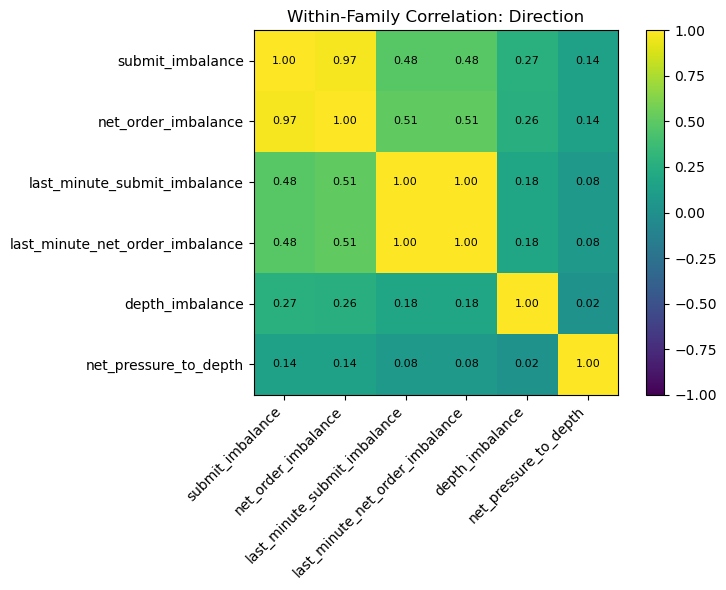

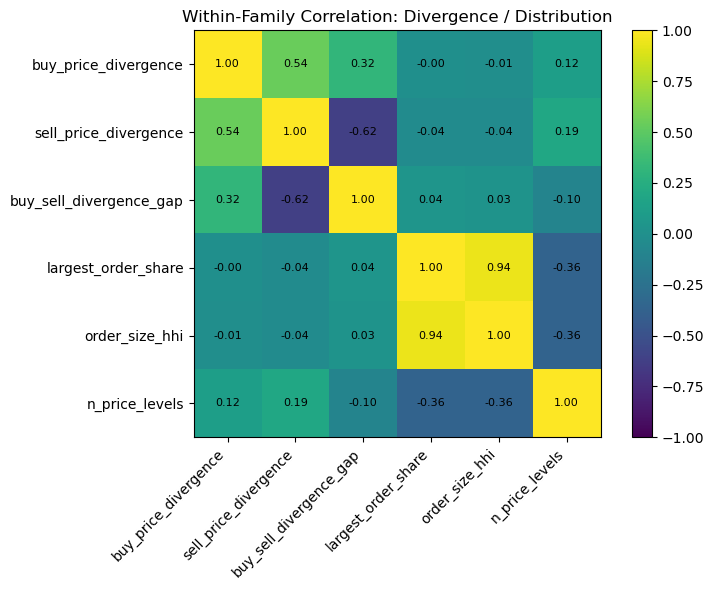

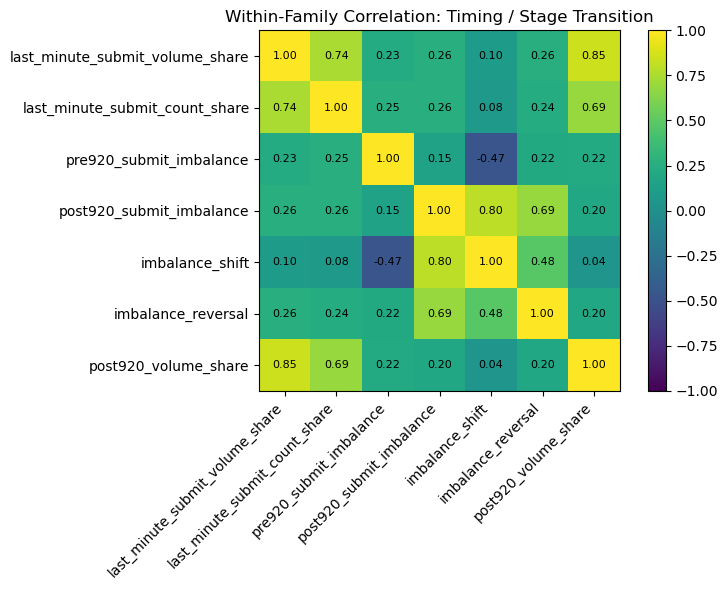

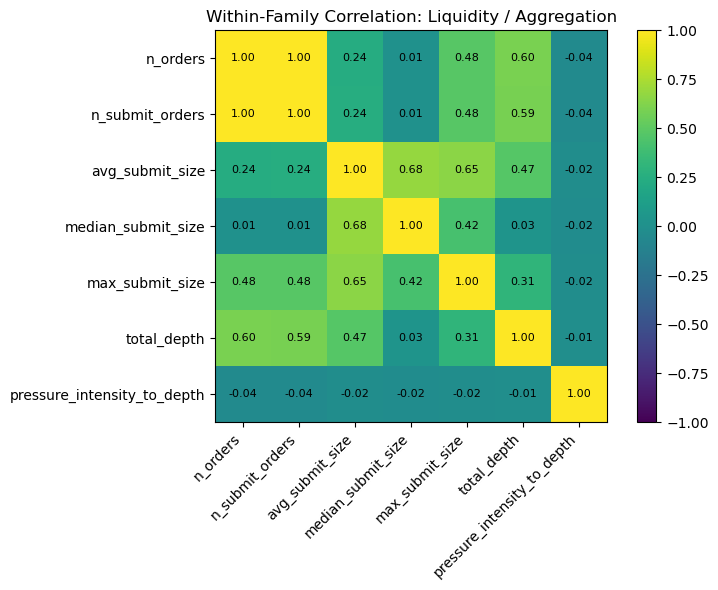

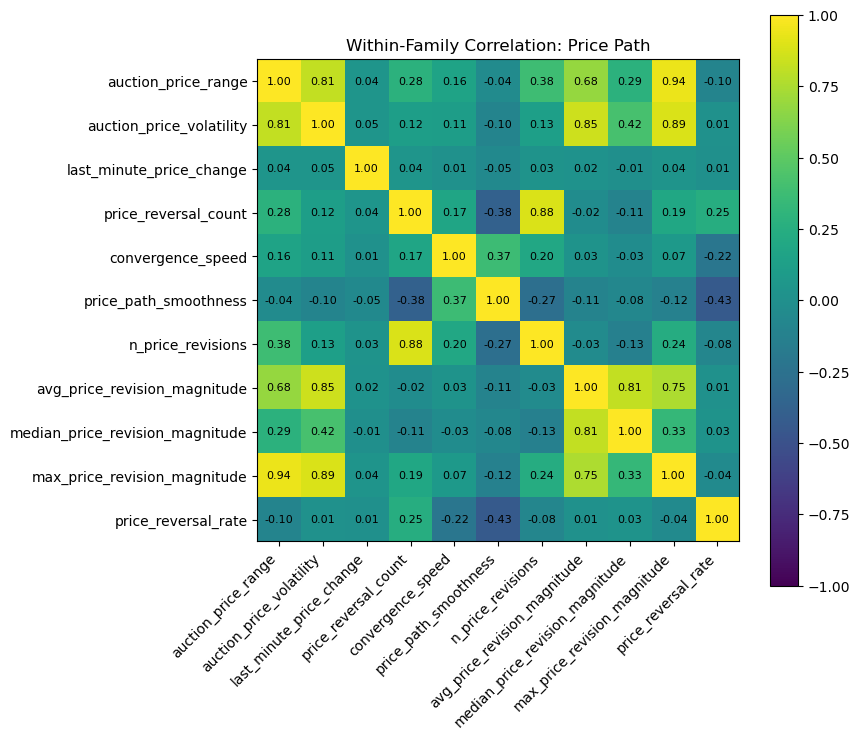

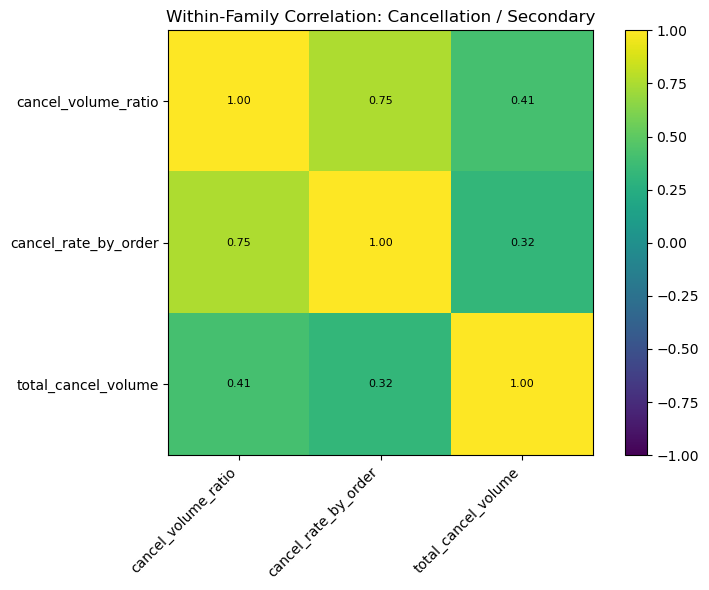

In [173]:
def plot_corr_heatmap(df, cols, title):
    existing = [c for c in cols if c in df.columns]

    if len(existing) < 2:
        print(f"Not enough features for {title}")
        return

    corr = df[existing].corr()

    fig, ax = plt.subplots(figsize=(max(8, len(existing) * 0.8), max(6, len(existing) * 0.7)))

    im = ax.imshow(corr, vmin=-1, vmax=1)

    ax.set_xticks(range(len(existing)))
    ax.set_yticks(range(len(existing)))
    ax.set_xticklabels(existing, rotation=45, ha="right")
    ax.set_yticklabels(existing)

    ax.set_title(title)

    for i in range(len(existing)):
        for j in range(len(existing)):
            value = corr.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


for family, cols in feature_family.items():
    plot_corr_heatmap(
        feature_df,
        cols,
        f"Within-Family Correlation: {family}"
    )

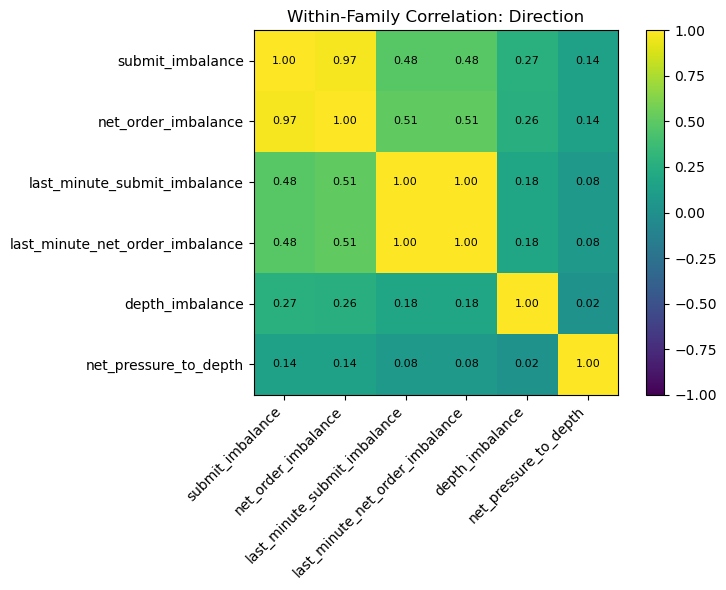

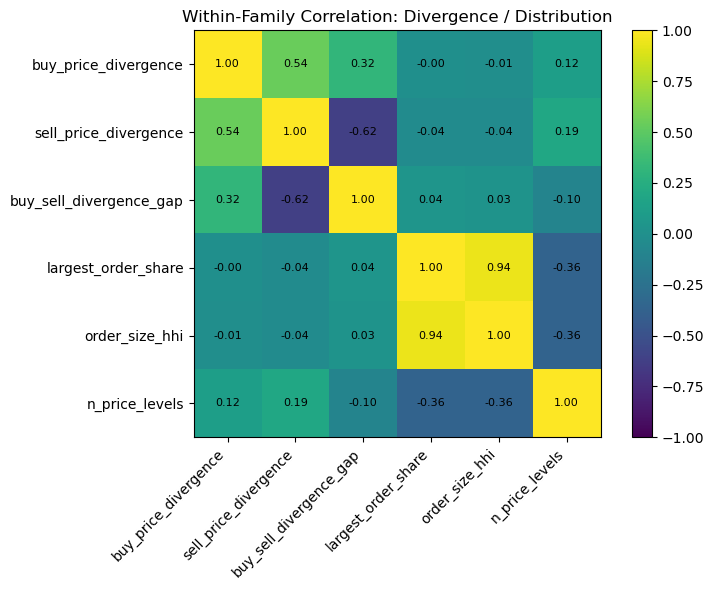

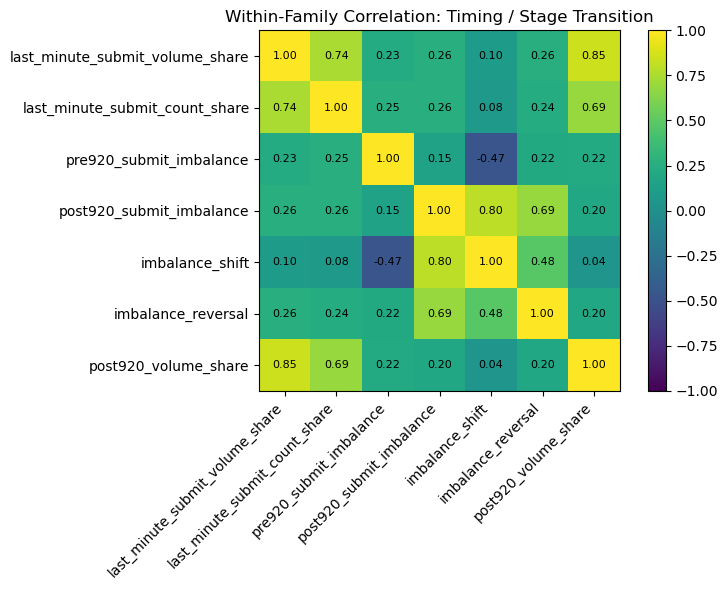

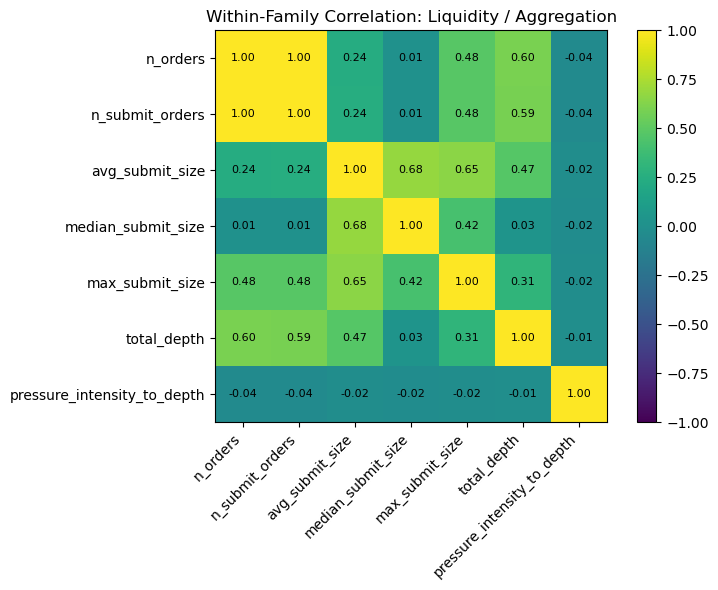

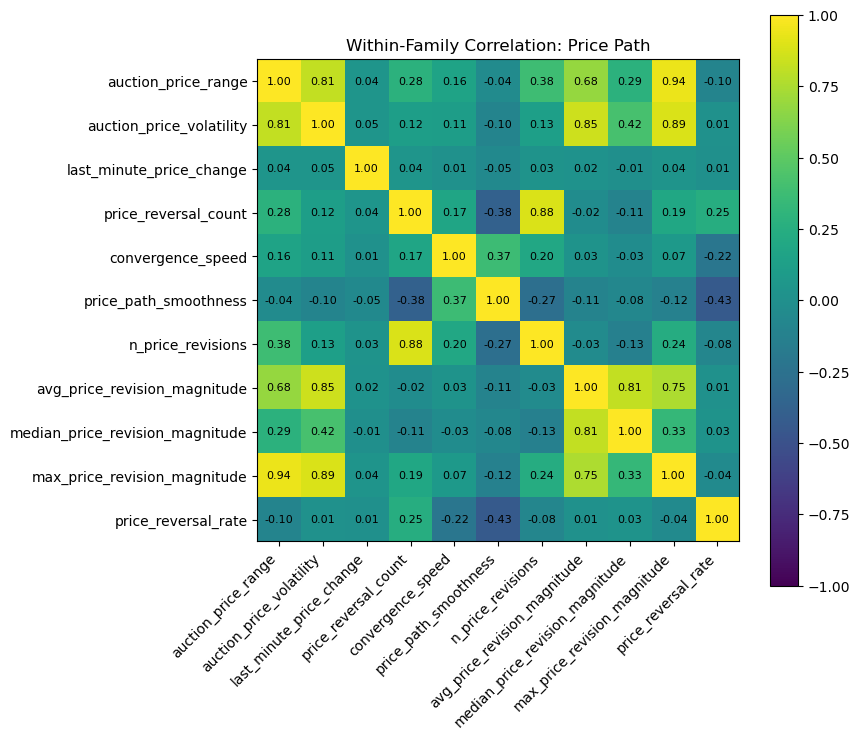

In [174]:
# Within-family correlation heatmaps
for family, cols in feature_family.items():
    if family == "Cancellation / Secondary":
        continue

    plot_corr_heatmap(
        feature_df,
        cols,
        f"Within-Family Correlation: {family}"
    )


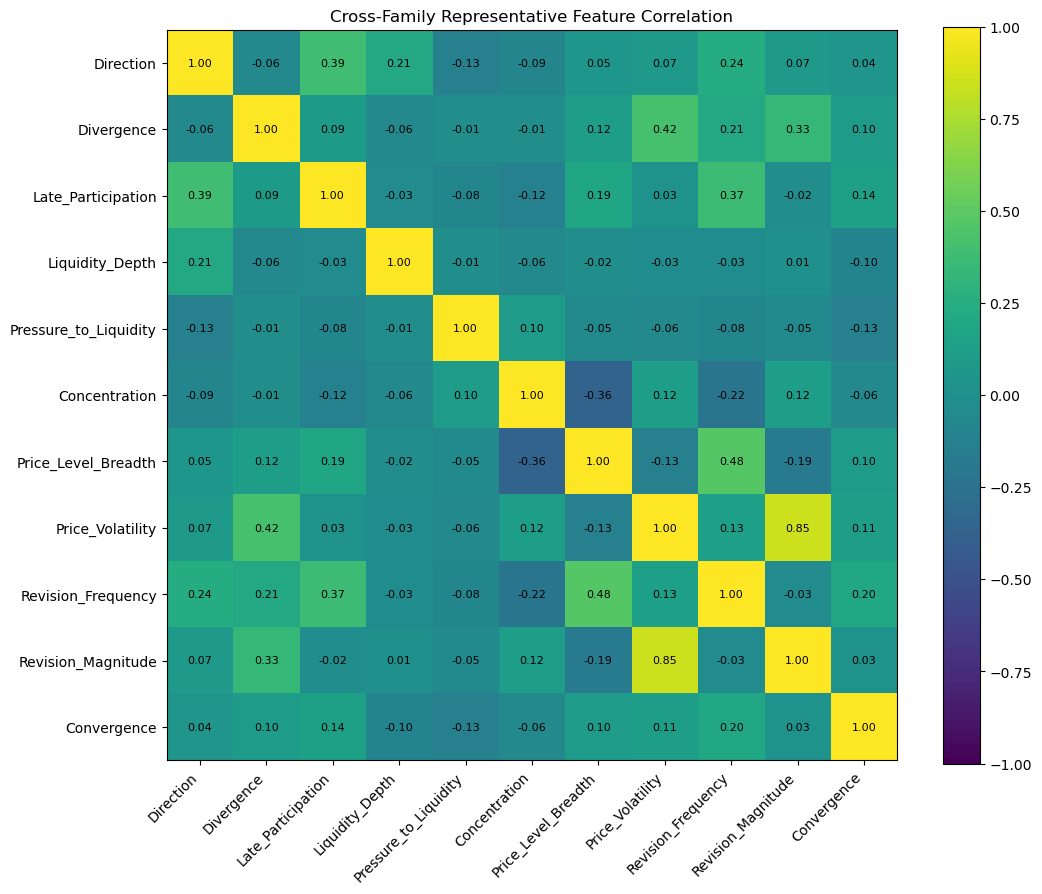

In [175]:
# Cross-family representative feature map
representative_features = {
    "Direction": "net_order_imbalance",
    "Divergence": "buy_price_divergence",
    "Late_Participation": "post920_volume_share",
    "Liquidity_Depth": "total_depth",
    "Pressure_to_Liquidity": "pressure_intensity_to_depth",
    "Concentration": "order_size_hhi",
    "Price_Level_Breadth": "n_price_levels",
    "Price_Volatility": "auction_price_volatility",
    "Revision_Frequency": "n_price_revisions",
    "Revision_Magnitude": "avg_price_revision_magnitude",
    "Convergence": "convergence_speed",
}

rep_cols = {
    label: col
    for label, col in representative_features.items()
    if col in feature_df.columns
}

rep_df = feature_df[list(rep_cols.values())].copy()
rep_df.columns = list(rep_cols.keys())

rep_corr = rep_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(rep_corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(rep_corr.columns)))
ax.set_yticks(range(len(rep_corr.index)))
ax.set_xticklabels(rep_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(rep_corr.index)
ax.set_title("Cross-Family Representative Feature Correlation")

for i in range(len(rep_corr.index)):
    for j in range(len(rep_corr.columns)):
        value = rep_corr.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Optional Exploratory Mechanism Checks

The following state analyses are kept as optional interpretation checks. They are useful for explaining why several feature families may matter, but they should **not** replace the next notebook's target-aware single-factor evaluation against `ret_0930_0935`.


In [176]:
# ============================================================
# Optional State 1: Divergence × Late-Stage Participation
# ============================================================

state_df = feature_df.copy()

divergence_feature = "buy_price_divergence"
late_participation_feature = "post920_volume_share"

state_df["divergence_state"] = np.where(
    state_df[divergence_feature] >= state_df[divergence_feature].median(),
    "High Divergence",
    "Low Divergence"
)

state_df["late_participation_state"] = np.where(
    state_df[late_participation_feature] >= state_df[late_participation_feature].median(),
    "High Late Participation",
    "Low Late Participation"
)

state_df["auction_state"] = (
    state_df["divergence_state"] + " × " + state_df["late_participation_state"]
)

state_order = [
    "Low Divergence × Low Late Participation",
    "Low Divergence × High Late Participation",
    "High Divergence × Low Late Participation",
    "High Divergence × High Late Participation",
]

state_df["auction_state"] = pd.Categorical(
    state_df["auction_state"],
    categories=state_order,
    ordered=True
)

state_summary = (
    state_df
    .groupby("auction_state", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_price_volatility=("auction_price_volatility", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
        avg_path_smoothness=("price_path_smoothness", "mean"),
    )
    .reindex(state_order)
)

display(state_summary.round(4))


,n_stock_days,avg_price_volatility,avg_price_reversal,avg_convergence_speed,avg_path_smoothness
auction_state,,,,,
Low Divergence × Low Late Participation,709,0.0023,3.2425,0.8395,0.4246
Low Divergence × High Late Participation,551,0.0025,4.5509,0.9490,0.4799
High Divergence × Low Late Participation,551,0.0064,4.4170,0.9094,0.3826
High Divergence × High Late Participation,709,0.0055,6.5348,0.9432,0.3815


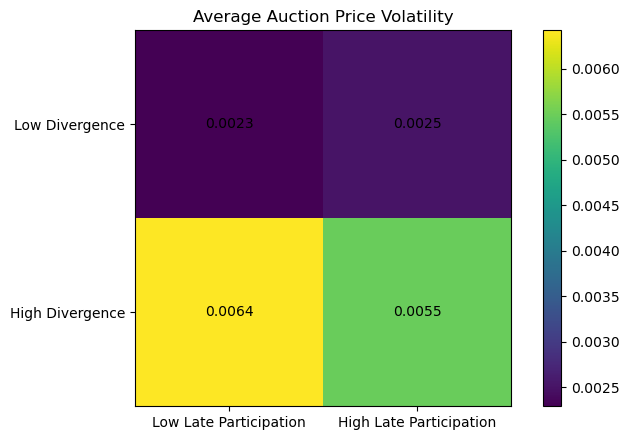

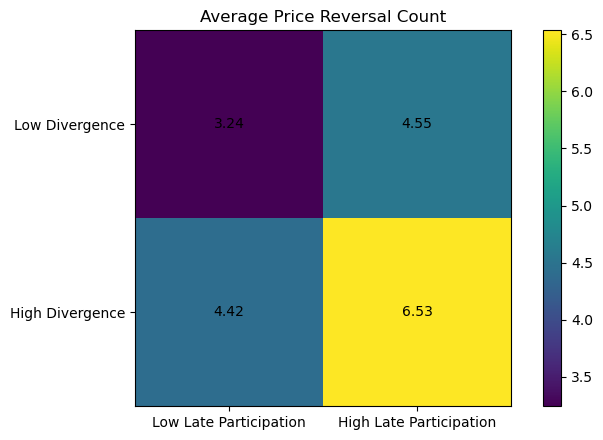

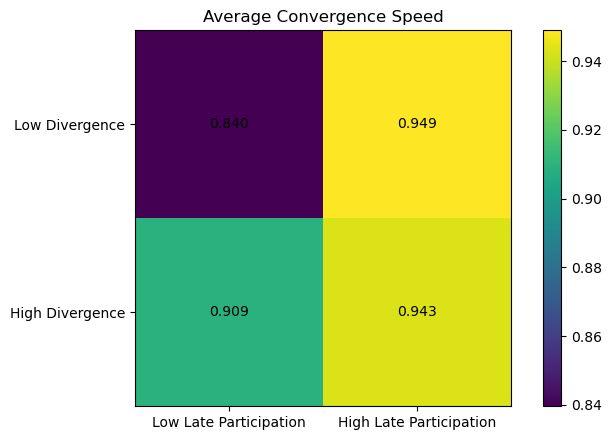

In [177]:
# Helper for 2×2 state heatmaps

def plot_2x2_state_heatmap(df, row_col, col_col, value_col, row_order, col_order, title, value_format=".3f"):
    matrix = (
        df
        .pivot_table(
            index=row_col,
            columns=col_col,
            values=value_col,
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=row_order, columns=col_order)
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(matrix.values)

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, format(matrix.iloc[i, j], value_format), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "auction_price_volatility",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Auction Price Volatility",
    ".4f"
)

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "price_reversal_count",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Price Reversal Count",
    ".2f"
)

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "convergence_speed",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Convergence Speed",
    ".3f"
)


In [178]:
# ============================================================
# Optional State 2: Updating Magnitude × Late-Stage Participation
# ============================================================

updating_state_df = feature_df.copy()
updating_state_df["updating_magnitude"] = updating_state_df["imbalance_shift"].abs()

updating_state_df["updating_state"] = np.where(
    updating_state_df["updating_magnitude"] >= updating_state_df["updating_magnitude"].median(),
    "High Updating",
    "Low Updating"
)

updating_state_df["late_participation_state"] = np.where(
    updating_state_df["post920_volume_share"] >= updating_state_df["post920_volume_share"].median(),
    "High Late Participation",
    "Low Late Participation"
)

updating_state_df["auction_state_2"] = (
    updating_state_df["updating_state"] + " × " + updating_state_df["late_participation_state"]
)

state_order_2 = [
    "Low Updating × Low Late Participation",
    "Low Updating × High Late Participation",
    "High Updating × Low Late Participation",
    "High Updating × High Late Participation",
]

updating_state_df["auction_state_2"] = pd.Categorical(
    updating_state_df["auction_state_2"],
    categories=state_order_2,
    ordered=True,
)

state_summary_2 = (
    updating_state_df
    .groupby("auction_state_2", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_updating_magnitude=("updating_magnitude", "mean"),
        avg_price_volatility=("auction_price_volatility", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
    )
    .reindex(state_order_2)
)

display(state_summary_2.round(4))


,n_stock_days,avg_updating_magnitude,avg_price_volatility,avg_price_reversal,avg_convergence_speed
auction_state_2,,,,,
Low Updating × Low Late Participation,694,0.1484,0.0037,3.7101,0.8708
Low Updating × High Late Participation,566,0.1547,0.0038,5.5745,0.9432
High Updating × Low Late Participation,566,0.6344,0.0045,3.8089,0.8692
High Updating × High Late Participation,694,0.6368,0.0045,5.7395,0.9478


,n_stock_days,avg_divergence,avg_n_price_levels,avg_n_price_revisions,avg_revision_magnitude,avg_price_reversal,avg_price_reversal_rate,avg_convergence_speed
auction_state_3,,,,,,,,
Low Divergence × Low Price-Level Breadth,743,0.0261,89.1750,5.0242,0.0059,2.8869,0.5496,0.8479
Low Divergence × High Price-Level Breadth,517,0.0287,222.8201,10.2631,0.0036,5.1393,0.5079,0.9439
High Divergence × Low Price-Level Breadth,507,0.0569,90.4675,7.4576,0.0132,3.8785,0.5117,0.9126
High Divergence × High Price-Level Breadth,753,0.0541,246.0624,14.0345,0.0058,6.7530,0.5067,0.9389


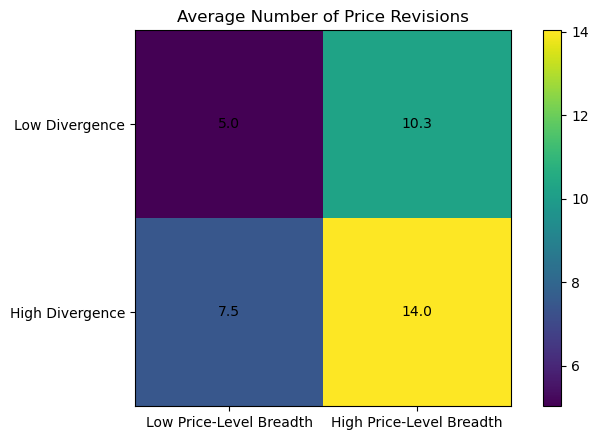

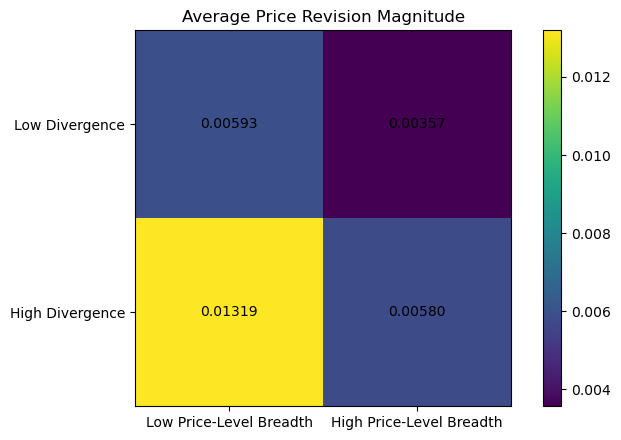

In [179]:
# ============================================================
# Optional State 3: Divergence × Price-Level Breadth
# ============================================================

breadth_state_df = feature_df.copy()

breadth_state_df["divergence_state"] = np.where(
    breadth_state_df["buy_price_divergence"] >= breadth_state_df["buy_price_divergence"].median(),
    "High Divergence",
    "Low Divergence"
)

breadth_state_df["breadth_state"] = np.where(
    breadth_state_df["n_price_levels"] >= breadth_state_df["n_price_levels"].median(),
    "High Price-Level Breadth",
    "Low Price-Level Breadth"
)

breadth_state_df["auction_state_3"] = (
    breadth_state_df["divergence_state"] + " × " + breadth_state_df["breadth_state"]
)

state_order_3 = [
    "Low Divergence × Low Price-Level Breadth",
    "Low Divergence × High Price-Level Breadth",
    "High Divergence × Low Price-Level Breadth",
    "High Divergence × High Price-Level Breadth",
]

breadth_state_df["auction_state_3"] = pd.Categorical(
    breadth_state_df["auction_state_3"],
    categories=state_order_3,
    ordered=True,
)

state_summary_3 = (
    breadth_state_df
    .groupby("auction_state_3", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_divergence=("buy_price_divergence", "mean"),
        avg_n_price_levels=("n_price_levels", "mean"),
        avg_n_price_revisions=("n_price_revisions", "mean"),
        avg_revision_magnitude=("avg_price_revision_magnitude", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_price_reversal_rate=("price_reversal_rate", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
    )
    .reindex(state_order_3)
)

display(state_summary_3.round(4))

plot_2x2_state_heatmap(
    breadth_state_df,
    "divergence_state",
    "breadth_state",
    "n_price_revisions",
    ["Low Divergence", "High Divergence"],
    ["Low Price-Level Breadth", "High Price-Level Breadth"],
    "Average Number of Price Revisions",
    ".1f"
)

plot_2x2_state_heatmap(
    breadth_state_df,
    "divergence_state",
    "breadth_state",
    "avg_price_revision_magnitude",
    ["Low Divergence", "High Divergence"],
    ["Low Price-Level Breadth", "High Price-Level Breadth"],
    "Average Price Revision Magnitude",
    ".5f"
)


## Single-Stock Multi-Day Auction Process

To complement the cross-sectional feature analysis, this section visualizes the intraday auction process for a single stock across multiple trading days.

The objective is to examine whether auction price formation, order-book imbalance, and visible depth exhibit persistent or heterogeneous temporal patterns across stock-days.

Three dimensions are considered:

- **Mid Price Path**: evolution of the best bid-ask midpoint during the auction.
- **Depth Imbalance**: directional asymmetry between visible bid and ask depth.
- **Total Depth**: evolution of visible order-book liquidity.

This visualization provides a path-level interpretation of the stock-day features constructed above.

Selected stock: 688599.SH
Selected dates: [Timestamp('2026-01-05 00:00:00'), Timestamp('2026-01-06 00:00:00'), Timestamp('2026-01-07 00:00:00'), Timestamp('2026-01-08 00:00:00'), Timestamp('2026-01-09 00:00:00')]


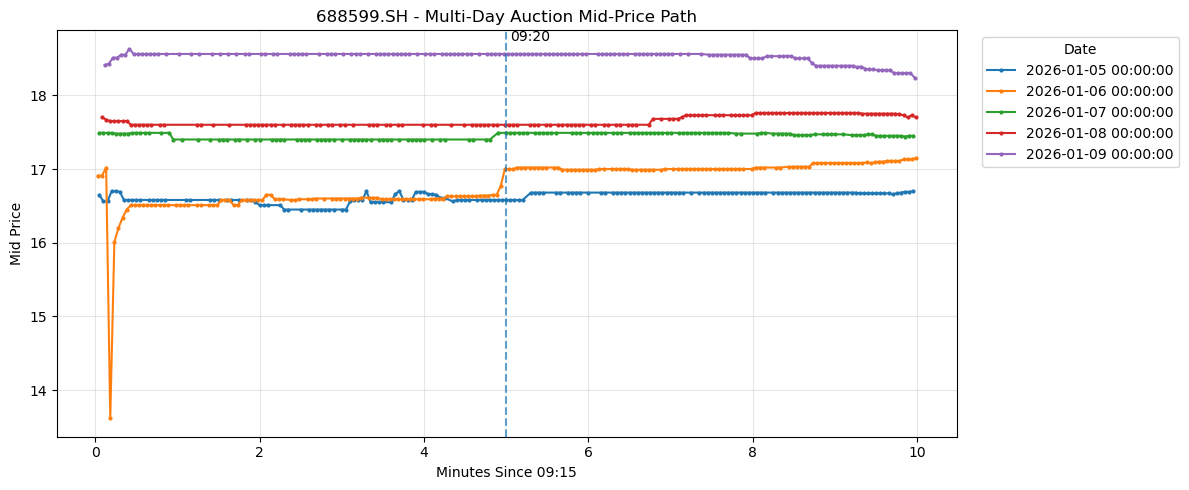

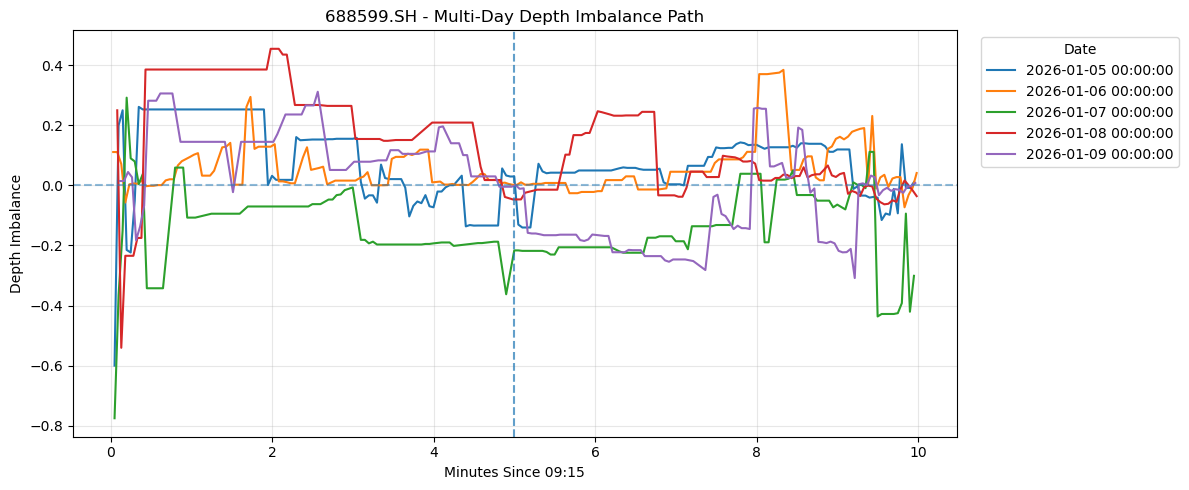

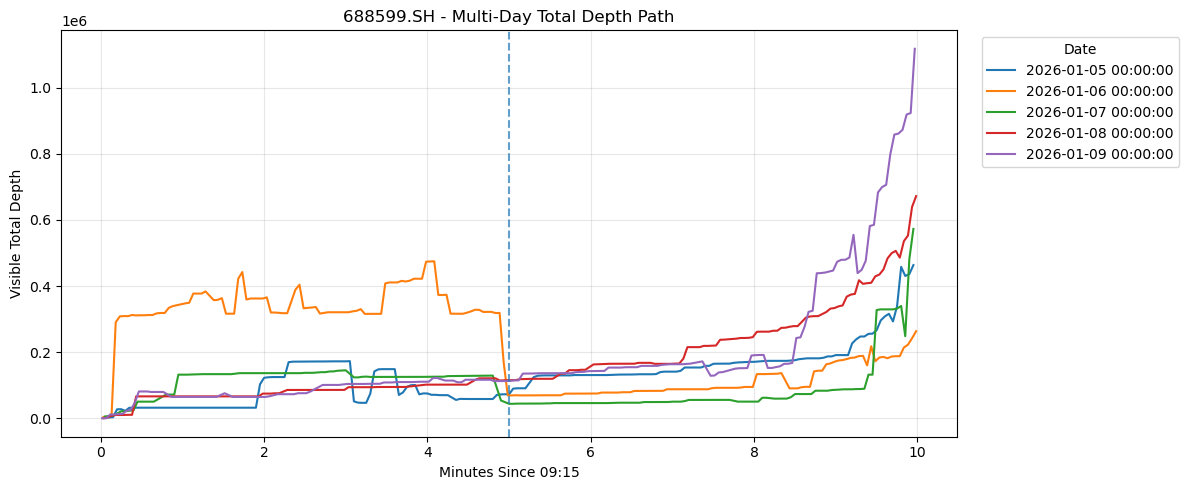

In [180]:
# ============================================================
# Single-Stock Multi-Day Auction Process
# ============================================================

plot_df = qtick_auction.copy()

# ------------------------------------------------------------
# 1. Reconstruct datetime if needed
# ------------------------------------------------------------

if "datetime" not in plot_df.columns:
    plot_df["datetime"] = pd.to_datetime(
        plot_df["date"].astype(str)
        + " "
        + plot_df["time"].astype(str)
    )

# ------------------------------------------------------------
# 2. Construct path variables
# ------------------------------------------------------------

bp0 = (
    pd.to_numeric(plot_df["bp0"], errors="coerce")
    .replace(0, np.nan)
)

ap0 = (
    pd.to_numeric(plot_df["ap0"], errors="coerce")
    .replace(0, np.nan)
)

plot_df["mid_price"] = (
    bp0 + ap0
) / 2


# Visible depth: bp0-bp9 / ap0-ap9
bid_volume_cols = [
    f"bv{i}"
    for i in range(10)
    if f"bv{i}" in plot_df.columns
]

ask_volume_cols = [
    f"av{i}"
    for i in range(10)
    if f"av{i}" in plot_df.columns
]


plot_df["bid_depth"] = (
    plot_df[bid_volume_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

plot_df["ask_depth"] = (
    plot_df[ask_volume_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

plot_df["total_depth"] = (
    plot_df["bid_depth"]
    + plot_df["ask_depth"]
)

plot_df["depth_imbalance"] = np.where(
    plot_df["total_depth"] > 0,
    (
        plot_df["bid_depth"]
        - plot_df["ask_depth"]
    )
    / plot_df["total_depth"],
    np.nan
)


# ------------------------------------------------------------
# 3. Select one stock and multiple dates
# ------------------------------------------------------------

selected_code = (
    plot_df["code"]
    .value_counts()
    .index[0]
)

available_dates = (
    plot_df.loc[
        plot_df["code"] == selected_code,
        "date"
    ]
    .drop_duplicates()
    .sort_values()
)

selected_dates = available_dates[:5]


single_stock_df = (
    plot_df[
        (plot_df["code"] == selected_code)
        & (plot_df["date"].isin(selected_dates))
    ]
    .copy()
)


print("Selected stock:", selected_code)

print(
    "Selected dates:",
    list(selected_dates)
)


# ------------------------------------------------------------
# 4. Create relative auction time
# ------------------------------------------------------------

single_stock_df["auction_minute"] = (
    single_stock_df["datetime"]
    - single_stock_df["datetime"].dt.normalize()
    - pd.Timedelta(hours=9, minutes=15)
).dt.total_seconds() / 60


# ============================================================
# Plot 1: Mid Price Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["mid_price"],
        marker="o",
        markersize=2,
        label=str(date)
    )

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.text(
    5.05,
    plt.ylim()[1],
    "09:20",
    va="top"
)

plt.title(
    f"{selected_code} - Multi-Day Auction Mid-Price Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Mid Price"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 2: Depth Imbalance Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["depth_imbalance"],
        label=str(date)
    )

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.title(
    f"{selected_code} - Multi-Day Depth Imbalance Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Depth Imbalance"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 3: Total Depth Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["total_depth"],
        label=str(date)
    )

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.title(
    f"{selected_code} - Multi-Day Total Depth Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Visible Total Depth"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Week 4 Feature Coverage Check

The final feature table now covers the required Week 4 feature directions:

- **Price Features**: auction price range, volatility, last-minute price change, price revision features
- **Order Features**: submitted volume, buy/sell volume, imbalance, order size, price-level distribution
- **Cancellation Features**: cancellation volume, cancellation ratio, order-level cancellation rate
- **Execution Features**: auction trade volume, trade amount, VWAP, trade count
- **Order Book Features**: bid/ask depth, depth imbalance, pressure-to-liquidity
- **Historical Features**: previous-day return, previous-day amount, rolling volatility, limit-distance controls

Market-level and sector-level features are not included at this stage due to data availability and are reserved for later model enhancement.

## Week 4 Output and Next Step

This notebook should stop at a prediction-ready auction feature table.

**Keep for next stage:**
- `feature_df`: stock-day auction feature table
- `feature_registry`: feature family / priority metadata
- `core_candidate_features`: first-pass candidate feature list
- `secondary_candidate_features`: cancellation and other lower-priority candidates

**Next notebook:** `05_5min_return_single_factor.ipynb`

Main task:
1. Construct `ret_0930_0935 = price_09:35 / price_09:30 - 1`.
2. Merge the 5-minute return label with `feature_df`.
3. Evaluate each feature as a single factor using IC, Rank IC, direction accuracy, and grouped returns.
4. Use target-aware results to decide which features survive.


In [181]:
# ============================================================
# Export Prediction-Ready Auction Features
# ============================================================

from pathlib import Path

AUCTION_FEATURE_PATH = Path(
    "../data/auction_features_prediction_ready.csv"
)

AUCTION_FEATURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

auction_feature_export = feature_df.copy()

auction_feature_export["date"] = (
    pd.to_datetime(
        auction_feature_export["date"]
    )
    .dt.strftime("%Y-%m-%d")
)

# Ensure one row per code-date
duplicate_keys = (
    auction_feature_export
    .duplicated(
        subset=[
            "code",
            "date"
        ]
    )
    .sum()
)

if duplicate_keys > 0:
    raise ValueError(
        "auction_feature_export contains "
        f"{duplicate_keys} duplicate code-date rows."
    )

required_prediction_columns = [
    "code",
    "date",
    "auction_price",
    "auction_price_nunique",
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "auction_vwap",
    "large_order_amount_share",
    "large_order_count_share",
    "large_order_imbalance",
    "post920_large_order_imbalance",
    "top5_order_amount_share",
    "order_amount_hhi"
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in auction_feature_export.columns
]

if missing_prediction_columns:
    raise KeyError(
        "Missing prediction-ready columns: "
        f"{missing_prediction_columns}"
    )

# Validate price scale before export
price_scale_check = (
    auction_feature_export[
        "auction_price"
    ]
    .dropna()
)

if (
    price_scale_check.median() > 1000
    or price_scale_check.median() <= 0
):
    raise ValueError(
        "auction_price appears to use an incorrect scale. "
        f"Median={price_scale_check.median()}"
    )

auction_feature_export.to_csv(
    AUCTION_FEATURE_PATH,
    index=False
)

print(
    "Auction features exported to:",
    AUCTION_FEATURE_PATH.resolve()
)

print(
    "Export shape:",
    auction_feature_export.shape
)

print(
    "Stocks:",
    auction_feature_export[
        "code"
    ].nunique()
)

print(
    "Dates:",
    auction_feature_export[
        "date"
    ].nunique()
)

print(
    "Duplicate code-date rows:",
    duplicate_keys
)

print(
    "Auction-price coverage:",
    auction_feature_export[
        "auction_price"
    ].notna().mean()
)

display(
    auction_feature_export[
        required_prediction_columns
    ].head(20)
)

Auction features exported to: C:\Users\work\OneDrive\Documents\level2-research\data\auction_features_prediction_ready.csv
Export shape: (2520, 82)
Stocks: 40
Dates: 63
Duplicate code-date rows: 0
Auction-price coverage: 0.9936507936507937


,code,date,auction_price,auction_price_nunique,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_vwap,large_order_amount_share,large_order_count_share,large_order_imbalance,post920_large_order_imbalance,top5_order_amount_share,order_amount_hhi
0,000713.SZ,2026-01-05,6.63,1.0,28.0,27900.0,184977.0,6.63,0.297778,0.007576,-1.000000,-1.000000,0.297778,0.028708
1,000713.SZ,2026-01-06,6.70,1.0,18.0,24200.0,162140.0,6.70,0.404593,0.017107,-1.000000,-1.000000,0.253780,0.023027
2,000713.SZ,2026-01-07,6.73,1.0,18.0,24800.0,166904.0,6.73,0.295135,0.012016,-0.727842,1.000000,0.223943,0.017076
3,000713.SZ,2026-01-08,6.74,1.0,22.0,36240.0,244257.6,6.74,0.367789,0.012384,-1.000000,0.000000,0.303582,0.026580
4,000713.SZ,2026-01-09,6.73,1.0,27.0,54700.0,368131.0,6.73,0.305438,0.010903,-1.000000,0.000000,0.261535,0.023382
5,000713.SZ,2026-01-12,6.77,1.0,34.0,58600.0,396722.0,6.77,0.279774,0.010219,-1.000000,-1.000000,0.233453,0.019630
6,000713.SZ,2026-01-13,6.83,1.0,38.0,143300.0,978739.0,6.83,0.210196,0.007663,-0.808953,-1.000000,0.193783,0.015246
7,000713.SZ,2026-01-14,6.80,1.0,32.0,50500.0,343400.0,6.80,0.318621,0.010116,-0.835717,-1.000000,0.272140,0.025450
8,000713.SZ,2026-01-15,6.77,1.0,25.0,60800.0,411616.0,6.77,0.435075,0.018625,-1.000000,-1.000000,0.257818,0.021976
9,000713.SZ,2026-01-16,6.82,1.0,17.0,26300.0,179366.0,6.82,0.373856,0.015320,-0.850613,-1.000000,0.227723,0.020065


In [182]:
# ============================================================
# Final Model-Ready Cleanup
# ============================================================

# 1. Remove diagnostic/non-predictive datetime fields
feature_df = feature_df.drop(
    columns=[
        "execution_first_time",
        "execution_last_time"
    ],
    errors="ignore"
)

# 2. Remove execution-price duplicate
feature_df = feature_df.drop(
    columns=[
        "auction_avg_trade_price"
    ],
    errors="ignore"
)

# 3. Preserve whether auction execution was observed
feature_df["has_auction_execution"] = (
    feature_df["auction_trade_count"]
    .notna()
    .astype(int)
)

# 4. No execution means zero count/volume/amount
execution_zero_cols = [
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount"
]

feature_df[execution_zero_cols] = (
    feature_df[execution_zero_cols]
    .fillna(0)
)

# 5. Final structural validation
assert not feature_df.duplicated(["code", "date"]).any()
assert not np.isinf(
    feature_df.select_dtypes(include=np.number)
).any().any()

print("Final feature_df shape:", feature_df.shape)
print("Stocks:", feature_df["code"].nunique())
print("Dates:", feature_df["date"].nunique())

display(
    feature_df[
        [
            "auction_trade_count",
            "auction_trade_volume",
            "auction_trade_amount",
            "auction_vwap",
            "has_auction_execution"
        ]
    ].isna().mean().rename("missing_rate")
)

Final feature_df shape: (2520, 81)
Stocks: 40
Dates: 63


auction_trade_count      0.000000
auction_trade_volume     0.000000
auction_trade_amount     0.000000
auction_vwap             0.006349
has_auction_execution    0.000000
Name: missing_rate, dtype: float64

In [183]:
# ============================================================
# Export feature table and feature registry for the next notebook
# ============================================================

feature_df.to_csv("04_auction_feature_table.csv", index=False)
feature_registry.to_csv("04_feature_registry.csv", index=False)

print("Saved:")
print("- 04_auction_feature_table.csv")
print("- 04_feature_registry.csv")
print("feature_df shape:", feature_df.shape)


Saved:
- 04_auction_feature_table.csv
- 04_feature_registry.csv
feature_df shape: (2520, 81)


In [184]:
export_check = pd.read_csv(
    AUCTION_FEATURE_PATH
)

print(
    [
        column
        for column in export_check.columns
        if (
            "auction_price" in column
            or "auction_trade" in column
        )
    ]
)

['auction_price_range', 'auction_price_volatility', 'auction_trade_count', 'auction_trade_volume', 'auction_trade_amount', 'auction_price', 'auction_price_nunique', 'auction_price_consistent']


# Part VIII. Large-Order Factor-Depth Factory

## 8.1 第一轮研究范围

第一轮只比较五个固定金额级别和两个最清晰的时间窗口：

```text
金额阈值：10万、30万、50万、100万、200万
时间窗口：full、post920
统计量：coverage、count share、amount share、imbalance、concentration
```

这样首先回答“大单究竟什么金额级别有效”，避免同时引入过多参数。

现有固定50万元宽表特征仍是母因子；本节生成的长表用于Notebook 05
做相同样本上的系统比较。


In [185]:
# ============================================================
# 8.2 Canonical Submit-Order Event Table
# ============================================================

from pathlib import Path

LARGE_ORDER_PRICE_SCALE = 10_000.0

required_large_order_event_columns = {
    "code",
    "date",
    "clock",
    "event_price",
    "event_volume",
    "is_submit",
    "is_buy",
    "is_sell",
}

missing_large_order_event_columns = sorted(
    required_large_order_event_columns.difference(
        events_auction.columns
    )
)

if missing_large_order_event_columns:
    raise KeyError(
        "events_auction missing factor-depth columns: "
        f"{missing_large_order_event_columns}"
    )

large_order_event_df = (
    events_auction.loc[
        events_auction["is_submit"].eq(1)
    ]
    .copy()
)

large_order_event_df["date"] = pd.to_datetime(
    large_order_event_df["date"]
).dt.normalize()

large_order_event_df["normalized_order_price"] = (
    pd.to_numeric(
        large_order_event_df["event_price"],
        errors="coerce",
    )
    /
    LARGE_ORDER_PRICE_SCALE
)

large_order_event_df["order_volume"] = pd.to_numeric(
    large_order_event_df["event_volume"],
    errors="coerce",
)

large_order_event_df["order_amount"] = (
    large_order_event_df["normalized_order_price"]
    *
    large_order_event_df["order_volume"]
)

# Convert clock to seconds after midnight so all window boundaries are explicit.
large_order_event_df["event_seconds"] = (
    pd.to_timedelta(
        large_order_event_df["clock"].astype(str)
    )
    .dt.total_seconds()
)

large_order_raw_n = len(large_order_event_df)

large_order_invalid_price_n = (
    ~np.isfinite(
        large_order_event_df["normalized_order_price"]
    )
    |
    large_order_event_df["normalized_order_price"].le(0)
).sum()

large_order_invalid_volume_n = (
    ~np.isfinite(
        large_order_event_df["order_volume"]
    )
    |
    large_order_event_df["order_volume"].le(0)
).sum()

large_order_unknown_side_n = (
    (
        large_order_event_df["is_buy"].eq(1).astype(int)
        +
        large_order_event_df["is_sell"].eq(1).astype(int)
    )
    != 1
).sum()

large_order_event_df = (
    large_order_event_df.loc[
        np.isfinite(
            large_order_event_df["normalized_order_price"]
        )
        &
        np.isfinite(
            large_order_event_df["order_volume"]
        )
        &
        np.isfinite(
            large_order_event_df["order_amount"]
        )
        &
        large_order_event_df["normalized_order_price"].gt(0)
        &
        large_order_event_df["order_volume"].gt(0)
        &
        large_order_event_df["order_amount"].gt(0)
        &
        large_order_event_df["event_seconds"].between(
            9 * 3600 + 15 * 60,
            9 * 3600 + 25 * 60,
            inclusive="both",
        )
        &
        (
            large_order_event_df["is_buy"].eq(1).astype(int)
            +
            large_order_event_df["is_sell"].eq(1).astype(int)
        ).eq(1)
    ]
    .copy()
)

if large_order_event_df.empty:
    raise ValueError(
        "No valid submit-order events remain for factor-depth analysis."
    )

large_order_event_quality = pd.DataFrame({
    "metric": [
        "raw_submit_events",
        "valid_submit_events",
        "invalid_price_rows",
        "invalid_volume_rows",
        "unknown_or_conflicting_side_rows",
        "n_stock_days",
        "n_dates",
        "n_stocks",
    ],
    "value": [
        large_order_raw_n,
        len(large_order_event_df),
        large_order_invalid_price_n,
        large_order_invalid_volume_n,
        large_order_unknown_side_n,
        large_order_event_df[
            ["code", "date"]
        ].drop_duplicates().shape[0],
        large_order_event_df["date"].nunique(),
        large_order_event_df["code"].nunique(),
    ],
})

display(large_order_event_quality)
display(large_order_event_df.head())


,metric,value
0,raw_submit_events,1972656
1,valid_submit_events,1972656
2,invalid_price_rows,0
3,invalid_volume_rows,0
4,unknown_or_conflicting_side_rows,0
5,n_stock_days,2520
6,n_dates,63
7,n_stocks,40


,code,date,time,datetime,clock,exchange,order_no,bs_flag,event_type,event_price,event_volume,source_table,is_submit,is_cancel,is_buy,is_sell,time_display,normalized_order_price,order_volume,order_amount,event_seconds
0,000713.SZ,2026-01-05,1970-01-01 09:15:00.000,2026-01-05 09:15:00-01:00,09:15:00,SZ,599,2,submit,63200.0,100,qorder,True,False,False,True,09:15:00.000,6.32,100,632.0,33300.00
1,000713.SZ,2026-01-05,1970-01-01 09:15:00.050,2026-01-05 09:15:00.050000-01:00,09:15:00.050000,SZ,3641,1,submit,64000.0,200,qorder,True,False,True,False,09:15:00.050,6.40,200,1280.0,33300.05
2,000713.SZ,2026-01-05,1970-01-01 09:15:00.050,2026-01-05 09:15:00.050000-01:00,09:15:00.050000,SZ,3818,2,submit,72800.0,1700,qorder,True,False,False,True,09:15:00.050,7.28,1700,12376.0,33300.05
3,000713.SZ,2026-01-05,1970-01-01 09:15:00.060,2026-01-05 09:15:00.060000-01:00,09:15:00.060000,SZ,6049,2,submit,66500.0,100,qorder,True,False,False,True,09:15:00.060,6.65,100,665.0,33300.06
4,000713.SZ,2026-01-05,1970-01-01 09:15:00.060,2026-01-05 09:15:00.060000-01:00,09:15:00.060000,SZ,6770,1,submit,65000.0,800,qorder,True,False,True,False,09:15:00.060,6.50,800,5200.0,33300.06


## 8.3 固定金额阈值与时间窗口

`full`覆盖整个09:15–09:25，`post920`从09:20开始，代表不可撤单阶段。
窗口边界统一使用秒数，09:20:00只属于`post920`。

无大单和大单买卖完全平衡是不同状态：

- 无大单：`coverage_flag = 0`，`large_order_imbalance = NaN`；
- 有大单但买卖金额相等：`coverage_flag = 1`，imbalance约为0。


In [186]:
# ============================================================
# 8.4 Fixed-Threshold × Window Long-Format Factory
# ============================================================

FIXED_LARGE_ORDER_THRESHOLDS = {
    "100k": 100_000.0,
    "300k": 300_000.0,
    "500k": 500_000.0,
    "1m": 1_000_000.0,
    "2m": 2_000_000.0,
}

LARGE_ORDER_WINDOWS = {
    "full": (
        9 * 3600 + 15 * 60,
        9 * 3600 + 25 * 60,
    ),
    "post920": (
        9 * 3600 + 20 * 60,
        9 * 3600 + 25 * 60,
    ),
}

large_order_stock_day_keys = (
    large_order_event_df[
        ["code", "date"]
    ]
    .drop_duplicates()
    .sort_values(["date", "code"])
    .reset_index(drop=True)
)


def _safe_ratio_series(numerator, denominator):
    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan)


def build_fixed_large_order_grid(
    event_df,
    stock_day_keys,
    thresholds,
    windows,
):
    output_parts = []

    for threshold_label, threshold_value in thresholds.items():
        for window_label, (start_seconds, end_seconds) in windows.items():

            window_events = event_df.loc[
                event_df["event_seconds"].between(
                    start_seconds,
                    end_seconds,
                    inclusive="both",
                )
            ].copy()

            window_totals = (
                window_events
                .groupby(
                    ["code", "date"],
                    as_index=False,
                    observed=True,
                )
                .agg(
                    total_order_count=("order_amount", "size"),
                    total_order_amount=("order_amount", "sum"),
                )
            )

            large_events = window_events.loc[
                window_events["order_amount"].ge(
                    threshold_value
                )
            ].copy()

            large_events["large_buy_amount_component"] = np.where(
                large_events["is_buy"].eq(1),
                large_events["order_amount"],
                0.0,
            )

            large_events["large_sell_amount_component"] = np.where(
                large_events["is_sell"].eq(1),
                large_events["order_amount"],
                0.0,
            )

            large_aggregates = (
                large_events
                .groupby(
                    ["code", "date"],
                    as_index=False,
                    observed=True,
                )
                .agg(
                    n_large_orders=("order_amount", "size"),
                    large_total_amount=("order_amount", "sum"),
                    large_buy_amount=(
                        "large_buy_amount_component",
                        "sum",
                    ),
                    large_sell_amount=(
                        "large_sell_amount_component",
                        "sum",
                    ),
                    largest_large_order_amount=(
                        "order_amount",
                        "max",
                    ),
                )
            )

            part = (
                stock_day_keys
                .merge(
                    window_totals,
                    on=["code", "date"],
                    how="left",
                    validate="one_to_one",
                )
                .merge(
                    large_aggregates,
                    on=["code", "date"],
                    how="left",
                    validate="one_to_one",
                )
            )

            count_columns = [
                "total_order_count",
                "n_large_orders",
            ]
            amount_columns = [
                "total_order_amount",
                "large_total_amount",
                "large_buy_amount",
                "large_sell_amount",
                "largest_large_order_amount",
            ]

            part[count_columns] = (
                part[count_columns]
                .fillna(0)
                .astype(int)
            )
            part[amount_columns] = part[amount_columns].fillna(0.0)

            large_direction_denominator = (
                part["large_buy_amount"]
                +
                part["large_sell_amount"]
            )

            part["coverage_flag"] = (
                part["n_large_orders"] > 0
            ).astype(int)

            part["large_order_imbalance"] = (
                _safe_ratio_series(
                    part["large_buy_amount"]
                    -
                    part["large_sell_amount"],
                    large_direction_denominator,
                )
            )

            part["large_amount_share"] = (
                _safe_ratio_series(
                    part["large_total_amount"],
                    part["total_order_amount"],
                )
            )

            part["large_count_share"] = (
                _safe_ratio_series(
                    part["n_large_orders"],
                    part["total_order_count"],
                )
            )

            part["largest_order_share"] = (
                _safe_ratio_series(
                    part["largest_large_order_amount"],
                    part["total_order_amount"],
                )
            )

            # Concentration contribution of large orders relative to all
            # submitted amount in the same stock-day/window.
            if large_events.empty:
                large_hhi = pd.DataFrame(
                    columns=[
                        "code",
                        "date",
                        "large_order_hhi",
                    ]
                )
            else:
                large_hhi_source = large_events.merge(
                    window_totals[
                        [
                            "code",
                            "date",
                            "total_order_amount",
                        ]
                    ],
                    on=["code", "date"],
                    how="left",
                    validate="many_to_one",
                )
                large_hhi_source["squared_total_amount_share"] = (
                    large_hhi_source["order_amount"]
                    /
                    large_hhi_source["total_order_amount"]
                ) ** 2
                large_hhi = (
                    large_hhi_source
                    .groupby(
                        ["code", "date"],
                        as_index=False,
                        observed=True,
                    )
                    .agg(
                        large_order_hhi=(
                            "squared_total_amount_share",
                            "sum",
                        )
                    )
                )

            part = part.merge(
                large_hhi,
                on=["code", "date"],
                how="left",
                validate="one_to_one",
            )

            part["large_order_hhi"] = (
                part["large_order_hhi"].fillna(0.0)
            )

            part["threshold_type"] = "fixed_amount"
            part["threshold_label"] = threshold_label
            part["threshold_value"] = float(threshold_value)
            part["auction_window"] = window_label
            part["window_start_seconds"] = start_seconds
            part["window_end_seconds"] = end_seconds

            output_parts.append(part)

    result = pd.concat(
        output_parts,
        ignore_index=True,
    )

    key_columns = [
        "code",
        "date",
        "threshold_type",
        "threshold_label",
        "auction_window",
    ]

    if result.duplicated(key_columns).any():
        raise ValueError(
            "Duplicate keys in fixed large-order factor grid."
        )

    return (
        result
        .sort_values(
            [
                "date",
                "code",
                "threshold_value",
                "auction_window",
            ]
        )
        .reset_index(drop=True)
    )


large_order_factor_grid_long = build_fixed_large_order_grid(
    event_df=large_order_event_df,
    stock_day_keys=large_order_stock_day_keys,
    thresholds=FIXED_LARGE_ORDER_THRESHOLDS,
    windows=LARGE_ORDER_WINDOWS,
)

print(
    "Large-order grid rows:",
    len(large_order_factor_grid_long),
)
print(
    "Expected rows:",
    (
        len(large_order_stock_day_keys)
        * len(FIXED_LARGE_ORDER_THRESHOLDS)
        * len(LARGE_ORDER_WINDOWS)
    ),
)

display(large_order_factor_grid_long.head(20))


Large-order grid rows: 25200
Expected rows: 25200


,code,date,total_order_count,total_order_amount,n_large_orders,large_total_amount,large_buy_amount,large_sell_amount,largest_large_order_amount,coverage_flag,large_order_imbalance,large_amount_share,large_count_share,largest_order_share,large_order_hhi,threshold_type,threshold_label,threshold_value,auction_window,window_start_seconds,window_end_seconds
0,000713.SZ,2026-01-05,660,20274353.9,32,11705468.9,264912.0,11440556.9,2573480.0,1,-0.954737,0.577353,0.048485,0.126933,0.027966,fixed_amount,100k,100000.0,full,33300,33900
1,000713.SZ,2026-01-05,88,3203454.0,5,1542536.0,132600.0,1409936.0,728000.0,1,-0.828075,0.481523,0.056818,0.227255,0.073298,fixed_amount,100k,100000.0,post920,33600,33900
2,000713.SZ,2026-01-05,660,20274353.9,10,7994606.9,0.0,7994606.9,2573480.0,1,-1.000000,0.394321,0.015152,0.126933,0.026325,fixed_amount,300k,300000.0,full,33300,33900
3,000713.SZ,2026-01-05,88,3203454.0,2,1137136.0,0.0,1137136.0,728000.0,1,-1.000000,0.354972,0.022727,0.227255,0.067956,fixed_amount,300k,300000.0,post920,33600,33900
4,000713.SZ,2026-01-05,660,20274353.9,5,6037246.9,0.0,6037246.9,2573480.0,1,-1.000000,0.297778,0.007576,0.126933,0.024445,fixed_amount,500k,500000.0,full,33300,33900
5,000713.SZ,2026-01-05,88,3203454.0,1,728000.0,0.0,728000.0,728000.0,1,-1.000000,0.227255,0.011364,0.227255,0.051645,fixed_amount,500k,500000.0,post920,33600,33900
6,000713.SZ,2026-01-05,660,20274353.9,2,3978520.0,0.0,3978520.0,2573480.0,1,-1.000000,0.196234,0.003030,0.126933,0.020915,fixed_amount,1m,1000000.0,full,33300,33900
7,000713.SZ,2026-01-05,88,3203454.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,1m,1000000.0,post920,33600,33900
8,000713.SZ,2026-01-05,660,20274353.9,1,2573480.0,0.0,2573480.0,2573480.0,1,-1.000000,0.126933,0.001515,0.126933,0.016112,fixed_amount,2m,2000000.0,full,33300,33900
9,000713.SZ,2026-01-05,88,3203454.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,2m,2000000.0,post920,33600,33900


## 8.5 长表质量审计

这一部分只检查阈值是否产生足够覆盖和变异，不根据未来收益挑选阈值。
正常情况下，阈值越高：

- `coverage_ratio`和平均大单笔数下降；
- 单笔最大金额上升；
- 大单金额占比不一定单调；
- 极高阈值可能因覆盖不足而不适合正式研究。


In [ ]:
denominator_check = (
    large_order_factor_grid_long
    .groupby(
        ["code", "date", "auction_window"],
        observed=True,
    )
    .agg(
        count_versions=(
            "total_order_count",
            "nunique",
        ),
        amount_versions=(
            "total_order_amount",
            "nunique",
        ),
    )
)

display(
    denominator_check[
        (denominator_check["count_versions"] > 1)
        |
        (denominator_check["amount_versions"] > 1)
    ].head(20)
)

print(
    "Bad stock-date-window rows:",
    (
        (denominator_check["count_versions"] > 1)
        |
        (denominator_check["amount_versions"] > 1)
    ).sum()
)

In [187]:
# ============================================================
# 8.6 Factor-Grid Coverage and Variation Audit
# ============================================================

large_order_grid_quality = (
    large_order_factor_grid_long
    .groupby(
        [
            "threshold_type",
            "threshold_label",
            "threshold_value",
            "auction_window",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        n_stock_days=("code", "size"),
        n_dates=("date", "nunique"),
        n_stocks=("code", "nunique"),
        coverage_ratio=("coverage_flag", "mean"),
        mean_large_order_count=("n_large_orders", "mean"),
        median_large_order_count=("n_large_orders", "median"),
        mean_large_amount_share=("large_amount_share", "mean"),
        median_large_amount_share=("large_amount_share", "median"),
        mean_abs_large_imbalance=(
            "large_order_imbalance",
            lambda values: values.abs().mean(),
        ),
        imbalance_non_missing_ratio=(
            "large_order_imbalance",
            lambda values: values.notna().mean(),
        ),
    )
    .sort_values(
        ["auction_window", "threshold_value"]
    )
    .reset_index(drop=True)
)

expected_grid_rows = (
    len(large_order_stock_day_keys)
    * len(FIXED_LARGE_ORDER_THRESHOLDS)
    * len(LARGE_ORDER_WINDOWS)
)

# Total window activity must not depend on the large-order threshold.
# This catches stale/incorrect implementations that accidentally zero the
# denominator when a high-threshold configuration has no qualifying orders.
large_order_denominator_invariance = (
    large_order_factor_grid_long
    .groupby(
        ["code", "date", "auction_window"],
        observed=True,
    )
    .agg(
        n_unique_total_order_count=(
            "total_order_count",
            "nunique",
        ),
        n_unique_total_order_amount=(
            "total_order_amount",
            "nunique",
        ),
    )
)

assert (
    len(large_order_factor_grid_long)
    == expected_grid_rows
)

assert (
    large_order_denominator_invariance[
        "n_unique_total_order_count"
    ].max()
    == 1
), (
    "total_order_count changes across thresholds for the same "
    "stock-date-window."
)

assert (
    large_order_denominator_invariance[
        "n_unique_total_order_amount"
    ].max()
    == 1
), (
    "total_order_amount changes across thresholds for the same "
    "stock-date-window."
)

assert large_order_factor_grid_long[
    "coverage_flag"
].isin([0, 1]).all()

assert large_order_factor_grid_long[
    "large_amount_share"
].dropna().between(0, 1 + 1e-12).all()

assert large_order_factor_grid_long[
    "large_count_share"
].dropna().between(0, 1 + 1e-12).all()

assert large_order_factor_grid_long[
    "large_order_imbalance"
].dropna().between(-1 - 1e-12, 1 + 1e-12).all()

display(large_order_grid_quality)


,threshold_type,threshold_label,threshold_value,auction_window,n_stock_days,n_dates,n_stocks,coverage_ratio,mean_large_order_count,median_large_order_count,mean_large_amount_share,median_large_amount_share,mean_abs_large_imbalance,imbalance_non_missing_ratio
0,fixed_amount,100k,100000.0,full,2520,63,40,1.000000,58.785714,34.0,0.555406,0.557147,0.479035,1.000000
1,fixed_amount,300k,300000.0,full,2520,63,40,0.969841,16.346032,8.0,0.314376,0.305391,0.589365,0.969841
2,fixed_amount,500k,500000.0,full,2520,63,40,0.892857,8.834127,3.0,0.221303,0.204998,0.673413,0.892857
3,fixed_amount,1m,1000000.0,full,2520,63,40,0.642857,3.919841,1.0,0.122224,0.094700,0.773952,0.642857
4,fixed_amount,2m,2000000.0,full,2520,63,40,0.306349,1.750794,0.0,0.053062,0.000000,0.865208,0.306349
5,fixed_amount,100k,100000.0,post920,2520,63,40,0.982143,23.116270,10.0,0.513415,0.529933,0.528091,0.982143
6,fixed_amount,300k,300000.0,post920,2520,63,40,0.779762,6.491270,2.0,0.261105,0.253464,0.675412,0.779762
7,fixed_amount,500k,500000.0,post920,2520,63,40,0.578571,3.359921,1.0,0.167365,0.122664,0.738225,0.578571
8,fixed_amount,1m,1000000.0,post920,2520,63,40,0.311905,1.276984,0.0,0.080072,0.000000,0.805685,0.311905
9,fixed_amount,2m,2000000.0,post920,2520,63,40,0.134921,0.408333,0.0,0.031318,0.000000,0.865465,0.134921


In [188]:
# ============================================================
# 8.7 Export Factor-Depth Research Tables
# ============================================================

LARGE_ORDER_GRID_PATH = Path(
    "04_large_order_factor_grid_long.csv"
)

LARGE_ORDER_GRID_QUALITY_PATH = Path(
    "04_large_order_factor_grid_quality.csv"
)

large_order_grid_export = (
    large_order_factor_grid_long.copy()
)
large_order_grid_export["date"] = (
    pd.to_datetime(
        large_order_grid_export["date"]
    )
    .dt.strftime("%Y-%m-%d")
)

large_order_grid_export.to_csv(
    LARGE_ORDER_GRID_PATH,
    index=False,
)

large_order_grid_quality.to_csv(
    LARGE_ORDER_GRID_QUALITY_PATH,
    index=False,
)

print(
    "Saved:",
    LARGE_ORDER_GRID_PATH.resolve(),
)
print(
    "Saved:",
    LARGE_ORDER_GRID_QUALITY_PATH.resolve(),
)


Saved: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_large_order_factor_grid_long.csv
Saved: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_large_order_factor_grid_quality.csv


## 8.8 后续深化协议

第一轮固定金额结果进入Notebook 05评价后，再按顺序扩展：

### 第二轮：相对规模

```text
stock-day P90 / P95 / P99
```

先回答固定金额与当日相对大单谁更稳定。

### 第三轮：历史异常规模

```text
当前订单金额 / 过去20日典型订单金额
2x / 5x / 10x
```

历史基准必须按股票并使用`shift(1)`，禁止包含当天。

### 第四轮：更细时间窗口

```text
pre920
post920
last60s
last30s
```

只有在阈值定义已经收敛后才加入最后60/30秒，避免阈值和窗口同时挖掘。

### 第五轮：动态机制

```text
late - early
方向持续
持续增强/衰减
买转卖
卖转买
大单与小单分歧
与严格09:30盘口确认
```

这些动态特征最终另存为
`04_large_order_dynamics_long.csv`。每一步都必须回到Notebook 05，与母因子
在相同样本上比较后再决定是否继续。


## 8.9 交付给Notebook 05的对象

| 对象 | 用途 |
|---|---|
| `04_auction_feature_table.csv` | 原有预测就绪宽表，继续兼容 |
| `04_feature_registry.csv` | 原有因子家族与元数据 |
| `04_large_order_factor_grid_long.csv` | 固定金额×窗口的大单实验长表 |
| `04_large_order_factor_grid_quality.csv` | 覆盖率和变异质量审计 |

Notebook 05只负责把长表与严格09:30→09:35标签合并，并统一计算IC、ICIR、
Q5−Q1、单调性和分层稳定性。Notebook 04不得根据未来收益修改阈值。
